# Notebook 4 — ECG Model Development

## Lightweight ECG Signal Classification Using Machine Learning and Deep Learning Models

This notebook begins the model development stage of the dissertation.

The modelling experiments use the final validated datasets produced by Notebook 3. The traditional machine-learning pathway uses nine time-domain ECG features, while the deep-learning pathway preserves the 2,500-sample ECG waveform from each validated 10-second window.

The primary objective is to evaluate and compare four focused baseline models:

- Logistic Regression
- Support Vector Machine (SVM)
- Lightweight Convolutional Neural Network (CNN)
- Lightweight Long Short-Term Memory network (LSTM)

The target variable is `WakeSleepLabel`.

Because the ECG windows use 50% overlap, individual windows must not be randomly distributed across training, validation, and test sets. All windows belonging to the same participant will remain within a single split to prevent information leakage caused by correlated observations from the same participant.

The modelling workflow will therefore:

1. Load the final Notebook 3 modelling datasets.
2. Verify dataset structure and integrity.
3. Inspect participant-level class distributions.
4. Construct a participant-level train/validation/test split.
5. Verify that no participant or window occurs across multiple splits.
6. Prepare and scale the ML feature dataset using training data only.
7. Train Logistic Regression and SVM baseline models.
8. Train compact CNN and LSTM models using the validated ECG waveforms.
9. Evaluate all models using consistent classification metrics.
10. Compare predictive performance with computational efficiency.

The core evaluation metrics will include accuracy, precision, recall, F1-score, and confusion matrices, with ROC-AUC considered where appropriate.

All modelling decisions will be made using the training and validation data. The test set will remain untouched until final evaluation.

Random seeds and model configurations will be recorded to support reproducibility.

## 1. Environment and Reproducibility

This section establishes the computational environment used for the modelling experiments.

The required Python libraries are imported and random seeds are configured to improve reproducibility across the machine-learning and deep-learning experiments. Specifically:

- A single global `SEED = 42` is used to initialise Python's `random` module, NumPy, and the `PYTHONHASHSEED` environment variable.
- `tf.random.set_seed(SEED)` additionally seeds TensorFlow/Keras, covering weight initialisation and any TensorFlow-level stochastic operations.
- The participant-level train/validation/test split (Section 3) is deterministic given the same seed and input data, so the composition of each split does not change across runs.
- The feature scaler used by the ML pathway (Section 4) is fitted exclusively on the training split and then applied to validation and test data, preventing information leakage from those splits into preprocessing.
- CNN and LSTM training uses fixed checkpointing (`ModelCheckpoint`, monitoring `val_auc`) and early stopping (`EarlyStopping`, `patience=3`, `restore_best_weights=True`), so the *procedure* for selecting the best epoch is deterministic and documented.

**Caveat on exact deep-learning reproducibility:** while the configuration, data split, and training procedure above are fully reproducible, exact bit-for-bit reproduction of CNN/LSTM weights across fresh runs is not guaranteed. This is a well-known property of GPU-accelerated deep learning, where operations such as cuDNN convolutions/LSTM kernels, parallel reduction order, and floating-point accumulation are not fully deterministic even with a fixed seed. The reported CNN and LSTM results in this notebook reflect the specific training run whose outputs are stored below; the seed and procedure are provided to make future runs as close as reasonably achievable, not to claim exact replication.

The modelling workflow is designed to maintain a consistent experimental configuration across Logistic Regression, Linear SVM, CNN, and LSTM models.

In [ ]:
# Cell 2 — Imports and Reproducibility Configuration

import os
import random
import time
import warnings

import tensorflow as tf

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

os.environ["PYTHONHASHSEED"] = str(SEED)

tf.random.set_seed(SEED)

print("Libraries imported successfully.")
print(f"Random seed: {SEED}")
print(f"TensorFlow global random seed set: {SEED}")

Libraries imported successfully.
Random seed: 42
TensorFlow global random seed set: 42


## 2. Loading the Validated Modelling Data

Notebook 4 uses the final validated modelling outputs produced by Notebook 3.

The purpose of this stage is to load the previously prepared ECG windows, labels, metadata, and feature representations without repeating the preprocessing performed in the earlier notebook.

The loaded data are subsequently checked for structural consistency before model development begins.

In [ ]:
# Cell 3 — Load Notebook 3 Exports

from google.colab import drive

# Mount Google Drive
drive.mount("/content/drive")

# Exact export directory established by Notebook 3
EXPORT_DIR = (
    "/content/drive/MyDrive/"
    "QMUL_MSc_Dissertation/"
    "Notebook3_Exports"
)

# Exact Notebook 3 export filenames
ML_FILE = os.path.join(
    EXPORT_DIR,
    "ML_feature_dataset.csv"
)

DL_FILE = os.path.join(
    EXPORT_DIR,
    "DL_window_metadata.csv"
)

FEATURE_FILE = os.path.join(
    EXPORT_DIR,
    "feature_columns.txt"
)

# Verify that all required files exist
required_files = {
    "ML feature dataset": ML_FILE,
    "DL window metadata": DL_FILE,
    "Feature list": FEATURE_FILE
}

print("Checking Notebook 3 exports...")
print("=" * 60)

for name, path in required_files.items():
    print(f"{name}: {'FOUND' if os.path.exists(path) else 'NOT FOUND'}")
    print(f"Path: {path}")
    print()

# Stop if any required file is missing
missing_files = [
    name for name, path in required_files.items()
    if not os.path.exists(path)
]

if missing_files:
    raise FileNotFoundError(
        "The following Notebook 3 export files are missing:\n"
        + "\n".join(missing_files)
    )

# Load datasets
ml_df = pd.read_csv(ML_FILE)
dl_df = pd.read_csv(DL_FILE)

# Load feature names
with open(FEATURE_FILE, "r") as f:
    feature_columns = [
        line.strip()
        for line in f
        if line.strip()
    ]

print("Notebook 3 exports loaded successfully.")
print("=" * 60)

print(f"ML dataset shape: {ml_df.shape}")
print(f"DL metadata shape: {dl_df.shape}")
print(f"Number of ML features: {len(feature_columns)}")

print("\nML feature columns:")
print(feature_columns)

print("\nML dataset columns:")
print(ml_df.columns.tolist())

print("\nDL metadata columns:")
print(dl_df.columns.tolist())

Mounted at /content/drive
Checking Notebook 3 exports...
ML feature dataset: FOUND
Path: /content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook3_Exports/ML_feature_dataset.csv

DL window metadata: FOUND
Path: /content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook3_Exports/DL_window_metadata.csv

Feature list: FOUND
Path: /content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook3_Exports/feature_columns.txt

Notebook 3 exports loaded successfully.
ML dataset shape: (421166, 15)
DL metadata shape: (421166, 10)
Number of ML features: 9

ML feature columns:
['Mean', 'Std', 'Min', 'Max', 'Range', 'Median', 'IQR', 'RMS', 'Energy']

ML dataset columns:
['WindowID', 'ParticipantID', 'ECGFile', 'StartTime', 'EndTime', 'WakeSleepLabel', 'Mean', 'Std', 'Min', 'Max', 'Range', 'Median', 'IQR', 'RMS', 'Energy']

DL metadata columns:
['WindowID', 'ParticipantID', 'ECGFile', 'StartTime', 'EndTime', 'WakeSleepLabel', 'Path', 'ActualFirstTimestamp', 'StartSample', 'EndSample']


In [ ]:
# Cell 4 — Dataset Structure and Integrity Check

print("Notebook 4 — Dataset Integrity Check")
print("=" * 70)



print("\n1. Dataset dimensions")
print("-" * 70)

print(f"ML dataset rows:        {len(ml_df):,}")
print(f"ML dataset columns:     {ml_df.shape[1]:,}")
print(f"DL metadata rows:       {len(dl_df):,}")
print(f"DL metadata columns:    {dl_df.shape[1]:,}")




required_ml_columns = [
    "WindowID",
    "ParticipantID",
    "ECGFile",
    "WakeSleepLabel"
]

required_dl_columns = [
    "WindowID",
    "ParticipantID",
    "ECGFile",
    "Path",
    "StartSample",
    "EndSample",
    "WakeSleepLabel"
]

print("\n2. Required column verification")
print("-" * 70)

missing_ml_columns = [
    col for col in required_ml_columns
    if col not in ml_df.columns
]

missing_dl_columns = [
    col for col in required_dl_columns
    if col not in dl_df.columns
]

print(
    "ML required columns:",
    "PASSED" if not missing_ml_columns else "FAILED"
)

if missing_ml_columns:
    print("Missing ML columns:", missing_ml_columns)

print(
    "DL required columns:",
    "PASSED" if not missing_dl_columns else "FAILED"
)

if missing_dl_columns:
    print("Missing DL columns:", missing_dl_columns)




print("\n3. ML feature verification")
print("-" * 70)

missing_features = [
    feature for feature in feature_columns
    if feature not in ml_df.columns
]

print(f"Expected ML features: {len(feature_columns)}")
print(f"Missing ML features:  {len(missing_features)}")

if missing_features:
    print("Missing features:", missing_features)
else:
    print("Feature column check: PASSED")




print("\n4. Target verification")
print("-" * 70)

print(f"Target column: WakeSleepLabel")
print(
    f"Missing target values: "
    f"{ml_df['WakeSleepLabel'].isna().sum():,}"
)

print(
    "Target validation:",
    "PASSED"
    if ml_df["WakeSleepLabel"].isna().sum() == 0
    else "FAILED"
)




print("\n5. Participant verification")
print("-" * 70)

print(
    f"Unique participants in ML dataset: "
    f"{ml_df['ParticipantID'].nunique():,}"
)

print(
    f"Unique participants in DL dataset: "
    f"{dl_df['ParticipantID'].nunique():,}"
)




print("\n6. Window verification")
print("-" * 70)

print(
    f"Unique ML WindowIDs: "
    f"{ml_df['WindowID'].nunique():,}"
)

print(
    f"Unique DL WindowIDs: "
    f"{dl_df['WindowID'].nunique():,}"
)

print(
    f"Duplicate ML WindowIDs: "
    f"{ml_df['WindowID'].duplicated().sum():,}"
)

print(
    f"Duplicate DL WindowIDs: "
    f"{dl_df['WindowID'].duplicated().sum():,}"
)




print("\n7. Feature completeness")
print("-" * 70)

feature_values = ml_df[feature_columns].to_numpy(
    dtype=np.float64
)

missing_feature_values = np.isnan(feature_values).sum()
infinite_feature_values = np.isinf(feature_values).sum()

print(f"Missing feature values:   {missing_feature_values:,}")
print(f"Infinite feature values:   {infinite_feature_values:,}")

print(
    "Feature completeness:",
    "PASSED"
    if missing_feature_values == 0
    and infinite_feature_values == 0
    else "FAILED"
)


# 8. ML/DL WindowID alignment


print("\n8. ML/DL window alignment")
print("-" * 70)

ml_window_ids = set(ml_df["WindowID"])
dl_window_ids = set(dl_df["WindowID"])

ml_only_windows = ml_window_ids - dl_window_ids
dl_only_windows = dl_window_ids - ml_window_ids

print(f"ML-only WindowIDs: {len(ml_only_windows):,}")
print(f"DL-only WindowIDs: {len(dl_only_windows):,}")

print(
    "ML/DL window alignment:",
    "PASSED"
    if len(ml_only_windows) == 0
    and len(dl_only_windows) == 0
    else "FAILED"
)



# Final status


all_checks_passed = (
    len(ml_df) == 421166
    and len(dl_df) == 421166
    and ml_df["ParticipantID"].nunique() == 30
    and dl_df["ParticipantID"].nunique() == 30
    and len(missing_ml_columns) == 0
    and len(missing_dl_columns) == 0
    and len(missing_features) == 0
    and ml_df["WakeSleepLabel"].isna().sum() == 0
    and missing_feature_values == 0
    and infinite_feature_values == 0
    and ml_df["WindowID"].duplicated().sum() == 0
    and dl_df["WindowID"].duplicated().sum() == 0
    and len(ml_only_windows) == 0
    and len(dl_only_windows) == 0
)

print("\n" + "=" * 70)
print(
    "OVERALL DATA INTEGRITY:",
    "PASSED" if all_checks_passed else "REQUIRES INVESTIGATION"
)
print("=" * 70)

Notebook 4 — Dataset Integrity Check

1. Dataset dimensions
----------------------------------------------------------------------
ML dataset rows:        421,166
ML dataset columns:     15
DL metadata rows:       421,166
DL metadata columns:    10

2. Required column verification
----------------------------------------------------------------------
ML required columns: PASSED
DL required columns: PASSED

3. ML feature verification
----------------------------------------------------------------------
Expected ML features: 9
Missing ML features:  0
Feature column check: PASSED

4. Target verification
----------------------------------------------------------------------
Target column: WakeSleepLabel
Missing target values: 0
Target validation: PASSED

5. Participant verification
----------------------------------------------------------------------
Unique participants in ML dataset: 30
Unique participants in DL dataset: 30

6. Window verification
---------------------------------------

## 3. Dataset Inspection and Participant-Level Data Splitting

Before model training, the validated dataset is inspected at participant level to understand the distribution of the target classes.

A participant-level train/validation/test split is then constructed. This is important because neighbouring ECG windows from the same participant may be highly correlated.

Keeping all windows from a participant within a single split reduces the risk of information leakage between training, validation, and test data.

The resulting split is explicitly checked to ensure that participants and windows do not overlap across subsets.

In [ ]:
# Cell 5 — Participant-Level Class Distribution

print("Notebook 4 — Participant-Level Class Distribution")
print("=" * 70)


# Create participant-level class distribution


participant_distribution = (
    ml_df
    .groupby(
        ["ParticipantID", "WakeSleepLabel"]
    )
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Ensure both classes are present as columns
if 0 not in participant_distribution.columns:
    participant_distribution[0] = 0

if 1 not in participant_distribution.columns:
    participant_distribution[1] = 0

participant_distribution = participant_distribution[[0, 1]]

participant_distribution.columns = [
    "Sleep_0",
    "Wake_1"
]


# Add totals and percentages


participant_distribution["Total"] = (
    participant_distribution["Sleep_0"]
    + participant_distribution["Wake_1"]
)

participant_distribution["Sleep_%"] = (
    participant_distribution["Sleep_0"]
    / participant_distribution["Total"]
    * 100
)

participant_distribution["Wake_%"] = (
    participant_distribution["Wake_1"]
    / participant_distribution["Total"]
    * 100
)



print("\nParticipant-level class distribution:")
print("-" * 70)

display(
    participant_distribution.round(2)
)



print("\nParticipant summary:")
print("-" * 70)

print(
    f"Participants: "
    f"{len(participant_distribution):,}"
)

print(
    f"Participants with Sleep windows: "
    f"{(participant_distribution['Sleep_0'] > 0).sum():,}"
)

print(
    f"Participants with Wake windows: "
    f"{(participant_distribution['Wake_1'] > 0).sum():,}"
)


# Identify relatively low representation


print("\nParticipants with relatively low Sleep representation:")
print("-" * 70)

low_sleep = participant_distribution[
    participant_distribution["Sleep_%"] < 10
]

if len(low_sleep) == 0:
    print("None")
else:
    display(low_sleep.round(2))


print("\nParticipants with relatively low Wake representation:")
print("-" * 70)

low_wake = participant_distribution[
    participant_distribution["Wake_%"] < 10
]

if len(low_wake) == 0:
    print("None")
else:
    display(low_wake.round(2))



# Overall class distribution


print("\nOverall class distribution:")
print("-" * 70)

overall_distribution = (
    ml_df["WakeSleepLabel"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Sleep",
        1: "Wake"
    })
)

overall_percentages = (
    overall_distribution
    / overall_distribution.sum()
    * 100
)

class_summary = pd.DataFrame({
    "Windows": overall_distribution,
    "Percentage": overall_percentages.round(2)
})

display(class_summary)

print("=" * 70)
print("Participant distribution inspection complete.")
print("No train/validation/test assignment has been performed.")
print("=" * 70)

Notebook 4 — Participant-Level Class Distribution

Participant-level class distribution:
----------------------------------------------------------------------


,Sleep_0,Wake_1,Total,Sleep_%,Wake_%
ParticipantID,,,,,
1,2196,11176,13372,16.42,83.58
2,4068,10731,14799,27.49,72.51
3,1793,12808,14601,12.28,87.72
4,3984,10339,14323,27.82,72.18
5,5097,9073,14170,35.97,64.03
6,2874,11450,14324,20.06,79.94
7,3272,11011,14283,22.91,77.09
8,2987,10646,13633,21.91,78.09
9,2518,11897,14415,17.47,82.53



Participant summary:
----------------------------------------------------------------------
Participants: 30
Participants with Sleep windows: 30
Participants with Wake windows: 30

Participants with relatively low Sleep representation:
----------------------------------------------------------------------


,Sleep_0,Wake_1,Total,Sleep_%,Wake_%
ParticipantID,,,,,
14,360,8127,8487,4.24,95.76



Participants with relatively low Wake representation:
----------------------------------------------------------------------
None

Overall class distribution:
----------------------------------------------------------------------


,Windows,Percentage
WakeSleepLabel,,
Sleep,87407,20.75
Wake,333759,79.25


Participant distribution inspection complete.
No train/validation/test assignment has been performed.


In [ ]:
# Cell 6 — Participant-Level Train/Validation/Test Split

print("Participant-Level Train/Validation/Test Split")
print("=" * 70)

# ------------------------------------------------------------
# Get participant-level information
# ------------------------------------------------------------

participant_ids = (
    ml_df["ParticipantID"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print(f"Total participants: {len(participant_ids)}")



# Calculate class proportions for each participant


participant_stats = (
    ml_df
    .groupby("ParticipantID")["WakeSleepLabel"]
    .agg(
        Total_Windows="count",
        Sleep_Windows=lambda x: (x == 0).sum(),
        Wake_Windows=lambda x: (x == 1).sum()
    )
    .reset_index()
)

participant_stats["Sleep_%"] = (
    participant_stats["Sleep_Windows"]
    / participant_stats["Total_Windows"]
    * 100
)

participant_stats["Wake_%"] = (
    participant_stats["Wake_Windows"]
    / participant_stats["Total_Windows"]
    * 100
)



# Shuffle participants reproducibly


rng = np.random.default_rng(SEED)

shuffled_participants = participant_ids.copy()
rng.shuffle(shuffled_participants)



# Initial approximate split


n_participants = len(shuffled_participants)

n_train = round(n_participants * 0.70)
n_validation = round(n_participants * 0.15)

# Ensure all participants are assigned
n_test = n_participants - n_train - n_validation

train_participants = sorted(
    shuffled_participants[:n_train]
)

validation_participants = sorted(
    shuffled_participants[
        n_train:n_train + n_validation
    ]
)

test_participants = sorted(
    shuffled_participants[
        n_train + n_validation:
    ]
)



# Display participant assignments

print("\nParticipant allocation")
print("-" * 70)

print(
    f"Training participants:   "
    f"{len(train_participants)}"
)

print(
    f"Validation participants: "
    f"{len(validation_participants)}"
)

print(
    f"Test participants:       "
    f"{len(test_participants)}"
)

print("\nTraining:")
print(train_participants)

print("\nValidation:")
print(validation_participants)

print("\nTest:")
print(test_participants)



# Create split labels for every window


def assign_split(participant_id):

    if participant_id in train_participants:
        return "train"

    elif participant_id in validation_participants:
        return "validation"

    elif participant_id in test_participants:
        return "test"

    else:
        return "unassigned"


ml_df["Split"] = (
    ml_df["ParticipantID"]
    .apply(assign_split)
)

dl_df["Split"] = (
    dl_df["ParticipantID"]
    .apply(assign_split)
)



# Verify that every window has been assigned


print("\nWindow assignment")
print("-" * 70)

print(
    ml_df["Split"]
    .value_counts()
    .sort_index()
)

unassigned_ml = (
    ml_df["Split"] == "unassigned"
).sum()

unassigned_dl = (
    dl_df["Split"] == "unassigned"
).sum()

print(
    f"\nUnassigned ML windows: {unassigned_ml:,}"
)

print(
    f"Unassigned DL windows: {unassigned_dl:,}"
)



# Class distribution by split


print("\nClass distribution by split")
print("-" * 70)

split_class_distribution = (
    ml_df
    .groupby(["Split", "WakeSleepLabel"])
    .size()
    .unstack(fill_value=0)
)

if 0 not in split_class_distribution.columns:
    split_class_distribution[0] = 0

if 1 not in split_class_distribution.columns:
    split_class_distribution[1] = 0

split_class_distribution = (
    split_class_distribution[[0, 1]]
)

split_class_distribution.columns = [
    "Sleep_0",
    "Wake_1"
]

split_class_distribution["Total"] = (
    split_class_distribution["Sleep_0"]
    + split_class_distribution["Wake_1"]
)

split_class_distribution["Sleep_%"] = (
    split_class_distribution["Sleep_0"]
    / split_class_distribution["Total"]
    * 100
)

split_class_distribution["Wake_%"] = (
    split_class_distribution["Wake_1"]
    / split_class_distribution["Total"]
    * 100
)

display(
    split_class_distribution.round(2)
)



# Participant counts by split


print("\nFinal participant counts")
print("-" * 70)

participant_split_summary = pd.DataFrame({
    "Split": [
        "Train",
        "Validation",
        "Test"
    ],
    "Participants": [
        len(train_participants),
        len(validation_participants),
        len(test_participants)
    ]
})

display(participant_split_summary)

print("=" * 70)
print("Participant-level split created.")
print("Leakage verification will be performed in the next cell.")
print("=" * 70)

Participant-Level Train/Validation/Test Split
Total participants: 30

Participant allocation
----------------------------------------------------------------------
Training participants:   21
Validation participants: 4
Test participants:       5

Training:
[1, 4, 6, 7, 8, 10, 11, 13, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 30]

Validation:
[3, 12, 15, 29]

Test:
[2, 5, 9, 14, 28]

Window assignment
----------------------------------------------------------------------
Split
test           65581
train         297867
validation     57718
Name: count, dtype: int64

Unassigned ML windows: 0
Unassigned DL windows: 0

Class distribution by split
----------------------------------------------------------------------


,Sleep_0,Wake_1,Total,Sleep_%,Wake_%
Split,,,,,
test,14923,50658,65581,22.76,77.24
train,62303,235564,297867,20.92,79.08
validation,10181,47537,57718,17.64,82.36



Final participant counts
----------------------------------------------------------------------


,Split,Participants
0,Train,21
1,Validation,4
2,Test,5


Participant-level split created.
Leakage verification will be performed in the next cell.


In [ ]:
# Cell 7 — Participant and Window Leakage Verification

print("Notebook 4 — Leakage Verification")
print("=" * 70)



train_set = set(train_participants)
validation_set = set(validation_participants)
test_set = set(test_participants)

train_validation_overlap = (
    train_set.intersection(validation_set)
)

train_test_overlap = (
    train_set.intersection(test_set)
)

validation_test_overlap = (
    validation_set.intersection(test_set)
)

print("\n1. Participant overlap")
print("-" * 70)

print(
    f"Train ∩ Validation: "
    f"{len(train_validation_overlap)}"
)

print(
    f"Train ∩ Test: "
    f"{len(train_test_overlap)}"
)

print(
    f"Validation ∩ Test: "
    f"{len(validation_test_overlap)}"
)

if train_validation_overlap:
    print("Overlapping participants:", train_validation_overlap)

if train_test_overlap:
    print("Overlapping participants:", train_test_overlap)

if validation_test_overlap:
    print("Overlapping participants:", validation_test_overlap)




train_window_ids = set(
    ml_df.loc[
        ml_df["Split"] == "train",
        "WindowID"
    ]
)

validation_window_ids = set(
    ml_df.loc[
        ml_df["Split"] == "validation",
        "WindowID"
    ]
)

test_window_ids = set(
    ml_df.loc[
        ml_df["Split"] == "test",
        "WindowID"
    ]
)

train_validation_window_overlap = (
    train_window_ids.intersection(
        validation_window_ids
    )
)

train_test_window_overlap = (
    train_window_ids.intersection(
        test_window_ids
    )
)

validation_test_window_overlap = (
    validation_window_ids.intersection(
        test_window_ids
    )
)

print("\n2. WindowID overlap")
print("-" * 70)

print(
    f"Train ∩ Validation: "
    f"{len(train_validation_window_overlap):,}"
)

print(
    f"Train ∩ Test: "
    f"{len(train_test_window_overlap):,}"
)

print(
    f"Validation ∩ Test: "
    f"{len(validation_test_window_overlap):,}"
)




print("\n3. Split assignment")
print("-" * 70)

print(
    f"Total ML windows: "
    f"{len(ml_df):,}"
)

print(
    f"Train windows: "
    f"{len(train_window_ids):,}"
)

print(
    f"Validation windows: "
    f"{len(validation_window_ids):,}"
)

print(
    f"Test windows: "
    f"{len(test_window_ids):,}"
)

total_split_windows = (
    len(train_window_ids)
    + len(validation_window_ids)
    + len(test_window_ids)
)

print(
    f"Total assigned windows: "
    f"{total_split_windows:,}"
)




participant_leakage_free = (
    len(train_validation_overlap) == 0
    and len(train_test_overlap) == 0
    and len(validation_test_overlap) == 0
)

window_leakage_free = (
    len(train_validation_window_overlap) == 0
    and len(train_test_window_overlap) == 0
    and len(validation_test_window_overlap) == 0
)

all_windows_assigned = (
    total_split_windows == len(ml_df)
)

no_unassigned_windows = (
    (ml_df["Split"] == "unassigned").sum() == 0
)

leakage_free = (
    participant_leakage_free
    and window_leakage_free
    and all_windows_assigned
    and no_unassigned_windows
)

print("\n" + "=" * 70)
print(
    "Participant separation:",
    "PASSED" if participant_leakage_free else "FAILED"
)

print(
    "Window separation:",
    "PASSED" if window_leakage_free else "FAILED"
)

print(
    "All windows assigned:",
    "PASSED" if all_windows_assigned else "FAILED"
)

print(
    "No unassigned windows:",
    "PASSED" if no_unassigned_windows else "FAILED"
)

print("-" * 70)

print(
    "OVERALL LEAKAGE CHECK:",
    "PASSED" if leakage_free else "FAILED"
)

print("=" * 70)

Notebook 4 — Leakage Verification

1. Participant overlap
----------------------------------------------------------------------
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

2. WindowID overlap
----------------------------------------------------------------------
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

3. Split assignment
----------------------------------------------------------------------
Total ML windows: 421,166
Train windows: 297,867
Validation windows: 57,718
Test windows: 65,581
Total assigned windows: 421,166

Participant separation: PASSED
Window separation: PASSED
All windows assigned: PASSED
No unassigned windows: PASSED
----------------------------------------------------------------------
OVERALL LEAKAGE CHECK: PASSED


In [ ]:
# Cell 8 — Create Split-Specific DataFrames

print("Creating split-specific datasets")
print("=" * 70)



ml_train = (
    ml_df[
        ml_df["Split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

ml_validation = (
    ml_df[
        ml_df["Split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

ml_test = (
    ml_df[
        ml_df["Split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)




dl_train = (
    dl_df[
        dl_df["Split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

dl_validation = (
    dl_df[
        dl_df["Split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

dl_test = (
    dl_df[
        dl_df["Split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)



print("\nML datasets")
print("-" * 70)

print(f"Training:   {len(ml_train):,}")
print(f"Validation: {len(ml_validation):,}")
print(f"Test:       {len(ml_test):,}")


print("\nDL metadata datasets")
print("-" * 70)

print(f"Training:   {len(dl_train):,}")
print(f"Validation: {len(dl_validation):,}")
print(f"Test:       {len(dl_test):,}")




print("\nML/DL split alignment")
print("-" * 70)

alignment_checks = {
    "Train": set(ml_train["WindowID"]) == set(dl_train["WindowID"]),
    "Validation": set(ml_validation["WindowID"]) == set(dl_validation["WindowID"]),
    "Test": set(ml_test["WindowID"]) == set(dl_test["WindowID"])
}

for split_name, passed in alignment_checks.items():
    print(
        f"{split_name}: "
        f"{'PASSED' if passed else 'FAILED'}"
    )



all_alignment_passed = all(
    alignment_checks.values()
)

print("\n" + "=" * 70)
print(
    "SPLIT DATASET PREPARATION:",
    "PASSED" if all_alignment_passed else "FAILED"
)
print("=" * 70)

Creating split-specific datasets

ML datasets
----------------------------------------------------------------------
Training:   297,867
Validation: 57,718
Test:       65,581

DL metadata datasets
----------------------------------------------------------------------
Training:   297,867
Validation: 57,718
Test:       65,581

ML/DL split alignment
----------------------------------------------------------------------
Train: PASSED
Validation: PASSED
Test: PASSED

SPLIT DATASET PREPARATION: PASSED


## 4. Traditional Machine-Learning Feature Preparation

The traditional machine-learning models operate on the nine validated time-domain ECG features generated during the preceding preprocessing stage.

The feature matrix is separated into training, validation, and test subsets using the participant-level split established above.

Feature scaling is subsequently fitted using the training data and applied consistently to the validation and test data. This prevents information from the validation or test sets influencing the preprocessing stage.

In [ ]:
# Cell 9 — ML Feature Matrix Preparation

print("ML Feature Matrix Preparation")
print("=" * 70)




X_train = ml_train[feature_columns].copy()
y_train = ml_train["WakeSleepLabel"].copy()

X_validation = ml_validation[feature_columns].copy()
y_validation = ml_validation["WakeSleepLabel"].copy()

X_test = ml_test[feature_columns].copy()
y_test = ml_test["WakeSleepLabel"].copy()




print("\n1. Feature columns")
print("-" * 70)

print(f"Number of features: {len(feature_columns)}")

for i, feature in enumerate(feature_columns, start=1):
    print(f"{i:2d}. {feature}")




print("\n2. Feature matrix dimensions")
print("-" * 70)

print(f"X_train:       {X_train.shape}")
print(f"X_validation:  {X_validation.shape}")
print(f"X_test:        {X_test.shape}")

print(f"y_train:       {y_train.shape}")
print(f"y_validation:  {y_validation.shape}")
print(f"y_test:        {y_test.shape}")



metadata_columns = [
    "WindowID",
    "ParticipantID",
    "ECGFile",
    "StartTime",
    "Split"
]

metadata_in_features = [
    column
    for column in metadata_columns
    if column in X_train.columns
]

print("\n3. Metadata exclusion check")
print("-" * 70)

print(
    "Metadata columns found in feature matrix:",
    metadata_in_features
    if metadata_in_features
    else "None"
)

metadata_excluded = (
    len(metadata_in_features) == 0
)

print(
    "Metadata exclusion:",
    "PASSED" if metadata_excluded else "FAILED"
)




print("\n4. Target verification")
print("-" * 70)

print(
    "Unique training labels:",
    sorted(y_train.unique().tolist())
)

print(
    "Unique validation labels:",
    sorted(y_validation.unique().tolist())
)

print(
    "Unique test labels:",
    sorted(y_test.unique().tolist())
)




print("\n5. Feature value validation")
print("-" * 70)

for name, X in [
    ("Training", X_train),
    ("Validation", X_validation),
    ("Test", X_test)
]:

    missing_values = X.isna().sum().sum()

    infinite_values = np.isinf(
        X.to_numpy(dtype=np.float64)
    ).sum()

    print(
        f"{name}: "
        f"missing={missing_values:,}, "
        f"infinite={infinite_values:,}"
    )



# Final status


feature_integrity_passed = (
    len(feature_columns) == 9
    and len(metadata_in_features) == 0
    and X_train.isna().sum().sum() == 0
    and X_validation.isna().sum().sum() == 0
    and X_test.isna().sum().sum() == 0
    and np.isinf(X_train.to_numpy(dtype=np.float64)).sum() == 0
    and np.isinf(X_validation.to_numpy(dtype=np.float64)).sum() == 0
    and np.isinf(X_test.to_numpy(dtype=np.float64)).sum() == 0
)

print("\n" + "=" * 70)
print(
    "ML FEATURE PREPARATION:",
    "PASSED" if feature_integrity_passed else "FAILED"
)
print("=" * 70)

ML Feature Matrix Preparation

1. Feature columns
----------------------------------------------------------------------
Number of features: 9
 1. Mean
 2. Std
 3. Min
 4. Max
 5. Range
 6. Median
 7. IQR
 8. RMS
 9. Energy

2. Feature matrix dimensions
----------------------------------------------------------------------
X_train:       (297867, 9)
X_validation:  (57718, 9)
X_test:        (65581, 9)
y_train:       (297867,)
y_validation:  (57718,)
y_test:        (65581,)

3. Metadata exclusion check
----------------------------------------------------------------------
Metadata columns found in feature matrix: None
Metadata exclusion: PASSED

4. Target verification
----------------------------------------------------------------------
Unique training labels: [0, 1]
Unique validation labels: [0, 1]
Unique test labels: [0, 1]

5. Feature value validation
----------------------------------------------------------------------
Training: missing=0, infinite=0
Validation: missing=0, infinite

In [ ]:
# Cell 10 — Feature Scaling

print("ML Feature Scaling")
print("=" * 70)




scaler = StandardScaler()



# Fit ONLY on training data

X_train_scaled = scaler.fit_transform(X_train)




X_validation_scaled = scaler.transform(
    X_validation
)

X_test_scaled = scaler.transform(
    X_test
)




X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_columns,
    index=X_train.index
)

X_validation_scaled = pd.DataFrame(
    X_validation_scaled,
    columns=feature_columns,
    index=X_validation.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_columns,
    index=X_test.index
)




print("\nScaled feature statistics")
print("-" * 70)

scaling_summary = pd.DataFrame({
    "Train_Mean": X_train_scaled.mean(),
    "Train_Std": X_train_scaled.std()
})

display(
    scaling_summary.round(4)
)



print("\nDataset dimensions after scaling")
print("-" * 70)

print(
    f"X_train_scaled:       "
    f"{X_train_scaled.shape}"
)

print(
    f"X_validation_scaled:  "
    f"{X_validation_scaled.shape}"
)

print(
    f"X_test_scaled:        "
    f"{X_test_scaled.shape}"
)




scaling_passed = (
    X_train_scaled.shape == X_train.shape
    and X_validation_scaled.shape == X_validation.shape
    and X_test_scaled.shape == X_test.shape
    and np.isfinite(
        X_train_scaled.to_numpy()
    ).all()
    and np.isfinite(
        X_validation_scaled.to_numpy()
    ).all()
    and np.isfinite(
        X_test_scaled.to_numpy()
    ).all()
)

print("\n" + "=" * 70)
print(
    "FEATURE SCALING:",
    "PASSED" if scaling_passed else "FAILED"
)
print("=" * 70)

ML Feature Scaling

Scaled feature statistics
----------------------------------------------------------------------


,Train_Mean,Train_Std
Mean,0.0,1.0
Std,-0.0,1.0
Min,0.0,1.0
Max,0.0,1.0
Range,-0.0,1.0
Median,0.0,1.0
IQR,-0.0,1.0
RMS,-0.0,1.0
Energy,-0.0,1.0



Dataset dimensions after scaling
----------------------------------------------------------------------
X_train_scaled:       (297867, 9)
X_validation_scaled:  (57718, 9)
X_test_scaled:        (65581, 9)

FEATURE SCALING: PASSED


## 5. Traditional Machine-Learning Baselines

Two lightweight traditional machine-learning models are evaluated as baseline approaches:

- Logistic Regression
- Linear Support Vector Machine (SVM)

These models provide computationally efficient reference points against which the deep-learning approaches can be compared.

Both models use the same participant-level data split and scaled feature representation to ensure a consistent experimental comparison.

In [ ]:
# Cell 11 — Logistic Regression Baseline

print("Logistic Regression Baseline")
print("=" * 70)



logistic_model = LogisticRegression(
    random_state=SEED,
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)



start_time = time.time()

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_training_time = (
    time.time() - start_time
)



start_time = time.time()

logistic_validation_pred = (
    logistic_model.predict(
        X_validation_scaled
    )
)

logistic_validation_prob = (
    logistic_model.predict_proba(
        X_validation_scaled
    )[:, 1]
)

logistic_prediction_time = (
    time.time() - start_time
)



logistic_validation_accuracy = accuracy_score(
    y_validation,
    logistic_validation_pred
)

logistic_validation_precision = precision_score(
    y_validation,
    logistic_validation_pred,
    zero_division=0
)

logistic_validation_recall = recall_score(
    y_validation,
    logistic_validation_pred,
    zero_division=0
)

logistic_validation_f1 = f1_score(
    y_validation,
    logistic_validation_pred,
    zero_division=0
)

logistic_validation_auc = roc_auc_score(
    y_validation,
    logistic_validation_prob
)



print("\nValidation Performance")
print("-" * 70)

print(
    f"Accuracy:       "
    f"{logistic_validation_accuracy:.4f}"
)

print(
    f"Precision:      "
    f"{logistic_validation_precision:.4f}"
)

print(
    f"Recall:         "
    f"{logistic_validation_recall:.4f}"
)

print(
    f"F1-score:       "
    f"{logistic_validation_f1:.4f}"
)

print(
    f"ROC-AUC:        "
    f"{logistic_validation_auc:.4f}"
)

print(
    f"\nTraining time:  "
    f"{logistic_training_time:.2f} seconds"
)

print(
    f"Prediction time:"
    f" {logistic_prediction_time:.2f} seconds"
)




logistic_validation_cm = confusion_matrix(
    y_validation,
    logistic_validation_pred
)

print("\nValidation Confusion Matrix")
print("-" * 70)

print(
    pd.DataFrame(
        logistic_validation_cm,
        index=["Actual Sleep", "Actual Wake"],
        columns=["Predicted Sleep", "Predicted Wake"]
    )
)




print("\nModel information")
print("-" * 70)

print(
    f"Number of coefficients: "
    f"{logistic_model.coef_.size:,}"
)

print(
    f"Intercept: "
    f"{logistic_model.intercept_[0]:.6f}"
)

print("=" * 70)
print("LOGISTIC REGRESSION TRAINING: COMPLETED")
print("=" * 70)

Logistic Regression Baseline

Validation Performance
----------------------------------------------------------------------
Accuracy:       0.2111
Precision:      0.6845
Recall:         0.0782
F1-score:       0.1403
ROC-AUC:        0.5341

Training time:  0.97 seconds
Prediction time: 0.02 seconds

Validation Confusion Matrix
----------------------------------------------------------------------
              Predicted Sleep  Predicted Wake
Actual Sleep             8468            1713
Actual Wake             43821            3716

Model information
----------------------------------------------------------------------
Number of coefficients: 9
Intercept: 0.041600
LOGISTIC REGRESSION TRAINING: COMPLETED


In [ ]:
# Cell 12 — Linear SVM Baseline

from sklearn.svm import LinearSVC

print("Linear SVM Baseline")
print("=" * 70)

# ------------------------------------------------------------
# Create Linear SVM model
# ------------------------------------------------------------

svm_model = LinearSVC(
    random_state=SEED,
    class_weight="balanced",
    max_iter=5000,
    C=1.0
)



start_time = time.time()

svm_model.fit(
    X_train_scaled,
    y_train
)

svm_training_time = (
    time.time() - start_time
)



start_time = time.time()

svm_validation_pred = (
    svm_model.predict(
        X_validation_scaled
    )
)

svm_validation_scores = (
    svm_model.decision_function(
        X_validation_scaled
    )
)

svm_prediction_time = (
    time.time() - start_time
)


svm_validation_accuracy = accuracy_score(
    y_validation,
    svm_validation_pred
)

svm_validation_precision = precision_score(
    y_validation,
    svm_validation_pred,
    zero_division=0
)

svm_validation_recall = recall_score(
    y_validation,
    svm_validation_pred,
    zero_division=0
)

svm_validation_f1 = f1_score(
    y_validation,
    svm_validation_pred,
    zero_division=0
)

svm_validation_auc = roc_auc_score(
    y_validation,
    svm_validation_scores
)




print("\nValidation Performance")
print("-" * 70)

print(
    f"Accuracy:        "
    f"{svm_validation_accuracy:.4f}"
)

print(
    f"Precision:       "
    f"{svm_validation_precision:.4f}"
)

print(
    f"Recall:          "
    f"{svm_validation_recall:.4f}"
)

print(
    f"F1-score:        "
    f"{svm_validation_f1:.4f}"
)

print(
    f"ROC-AUC:         "
    f"{svm_validation_auc:.4f}"
)

print(
    f"\nTraining time:   "
    f"{svm_training_time:.2f} seconds"
)

print(
    f"Prediction time: "
    f"{svm_prediction_time:.2f} seconds"
)


# ------------------------------------------------------------
# Validation confusion matrix
# ------------------------------------------------------------

svm_validation_cm = confusion_matrix(
    y_validation,
    svm_validation_pred
)

print("\nValidation Confusion Matrix")
print("-" * 70)

print(
    pd.DataFrame(
        svm_validation_cm,
        index=["Actual Sleep", "Actual Wake"],
        columns=["Predicted Sleep", "Predicted Wake"]
    )
)


# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------

print("\nModel information")
print("-" * 70)

print(
    f"Number of coefficients: "
    f"{svm_model.coef_.size:,}"
)

print(
    f"Intercept: "
    f"{svm_model.intercept_[0]:.6f}"
)

print("=" * 70)
print("LINEAR SVM TRAINING: COMPLETED")
print("=" * 70)

Linear SVM Baseline

Validation Performance
----------------------------------------------------------------------
Accuracy:        0.2091
Precision:       0.6905
Recall:          0.0720
F1-score:        0.1305
ROC-AUC:         0.5337

Training time:   0.69 seconds
Prediction time: 0.01 seconds

Validation Confusion Matrix
----------------------------------------------------------------------
              Predicted Sleep  Predicted Wake
Actual Sleep             8646            1535
Actual Wake             44112            3425

Model information
----------------------------------------------------------------------
Number of coefficients: 9
Intercept: 0.014686
LINEAR SVM TRAINING: COMPLETED


## 6. Deep-Learning Data Preparation and Waveform Verification

The deep-learning pathway operates directly on the reconstructed ECG waveform rather than the nine engineered time-domain features used by the traditional ML models.

Each modelling window represents 10 seconds of ECG sampled at 250 Hz, resulting in 2,500 waveform samples per input window.

The ECG archive, waveform metadata, and reconstructed windows are therefore verified before the computationally more expensive deep-learning experiments are started.

In [ ]:
# Cell 13 — Prepare Deep Learning Data Source

import zipfile

print("Deep Learning Data Source Preparation")
print("=" * 70)

# ------------------------------------------------------------
# Original ECG archive established in Notebook 2
# ------------------------------------------------------------

ZIP_PATH = (
    "/content/drive/MyDrive/"
    "QMUL_MSc_Dissertation/"
    "Per_Participant_Sensor_Data.zip"
)

print("\n1. ECG archive verification")
print("-" * 70)

print(f"Archive path:\n{ZIP_PATH}")

if not os.path.exists(ZIP_PATH):
    raise FileNotFoundError(
        f"ECG archive not found:\n{ZIP_PATH}"
    )

if not zipfile.is_zipfile(ZIP_PATH):
    raise ValueError(
        "The ECG archive is not a valid ZIP file."
    )

print("ECG archive: FOUND")
print("ZIP validation: PASSED")


# ------------------------------------------------------------
# Inspect archive structure
# ------------------------------------------------------------

print("\n2. Archive structure inspection")
print("-" * 70)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    archive_members = z.namelist()

print(
    f"Total archive members: "
    f"{len(archive_members):,}"
)

# Find ECG CSV files
ecg_members = [
    member
    for member in archive_members
    if member.lower().endswith(".csv")
    and "ecg" in os.path.basename(member).lower()
]

print(
    f"ECG CSV files found: "
    f"{len(ecg_members):,}"
)

print("\nFirst 10 ECG files:")

for member in ecg_members[:10]:
    print(member)


# ------------------------------------------------------------
# Verify metadata paths against the archive
# ------------------------------------------------------------

print("\n3. DL metadata path verification")
print("-" * 70)

metadata_paths = (
    dl_df["Path"]
    .dropna()
    .astype(str)
    .unique()
)

print(
    f"Unique ECG paths in DL metadata: "
    f"{len(metadata_paths):,}"
)


archive_member_set = set(archive_members)

paths_found = sum(
    path in archive_member_set
    for path in metadata_paths
)

paths_missing = (
    len(metadata_paths) - paths_found
)

print(
    f"Paths found in archive: "
    f"{paths_found:,}"
)

print(
    f"Paths missing from archive: "
    f"{paths_missing:,}"
)


# ------------------------------------------------------------
# Show missing paths if any
# ------------------------------------------------------------

if paths_missing > 0:

    print("\nMissing metadata paths:")
    print("-" * 70)

    missing_paths = [
        path
        for path in metadata_paths
        if path not in archive_member_set
    ]

    for path in missing_paths[:10]:
        print(path)

    if len(missing_paths) > 10:
        print(
            f"... and "
            f"{len(missing_paths) - 10:,} more."
        )




print("\n4. Waveform window configuration")
print("-" * 70)

SAMPLE_RATE = 250
WINDOW_SAMPLES = 2500
WINDOW_SECONDS = 10

print(f"Sampling rate:     {SAMPLE_RATE} Hz")
print(f"Window duration:   {WINDOW_SECONDS} seconds")
print(f"Samples per window:{WINDOW_SAMPLES}")


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

dl_source_ready = (
    os.path.exists(ZIP_PATH)
    and zipfile.is_zipfile(ZIP_PATH)
    and len(metadata_paths) > 0
    and paths_missing == 0
)

print("\n" + "=" * 70)

print(
    "DL DATA SOURCE:",
    "READY" if dl_source_ready else "REQUIRES INVESTIGATION"
)

print("=" * 70)

Deep Learning Data Source Preparation

1. ECG archive verification
----------------------------------------------------------------------
Archive path:
/content/drive/MyDrive/QMUL_MSc_Dissertation/Per_Participant_Sensor_Data.zip
ECG archive: FOUND
ZIP validation: PASSED

2. Archive structure inspection
----------------------------------------------------------------------
Total archive members: 585
ECG CSV files found: 58

First 10 ECG files:
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__10_28_26_ECG.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_06__15_38_43_ECG.csv
Per_Participant_Sensor_Data/001/001_Zephyr/2022_06_07__10_42_46_ECG.csv
Per_Participant_Sensor_Data/002/002_Zephyr/2022_06_21__08_03_26_ECG.csv
Per_Participant_Sensor_Data/002/002_Zephyr/2022_06_21__08_43_49_ECG.csv
Per_Participant_Sensor_Data/002/002_Zephyr/2022_06_21__11_53_12_ECG.csv
Per_Participant_Sensor_Data/003/003_Zephyr/2022_08_01__09_38_43_ECG.csv
Per_Participant_Sensor_Data/003/003_Zephyr/2022_0

In [ ]:
# Cell 14 — Verify a Sample ECG Waveform

print("ECG Waveform Reconstruction Test")
print("=" * 70)

# ------------------------------------------------------------
# Select one validated training window
# ------------------------------------------------------------

sample_metadata = dl_train.iloc[0]

sample_path = sample_metadata["Path"]
sample_start = int(sample_metadata["StartSample"])
sample_end = int(sample_metadata["EndSample"])

print("\n1. Selected window")
print("-" * 70)

print(
    f"WindowID:       {sample_metadata['WindowID']}"
)

print(
    f"ParticipantID:  {sample_metadata['ParticipantID']}"
)

print(
    f"ECGFile:        {sample_metadata['ECGFile']}"
)

print(
    f"Start sample:   {sample_start}"
)

print(
    f"End sample:     {sample_end}"
)

print(
    f"Expected samples: "
    f"{sample_end - sample_start}"
)


# ------------------------------------------------------------
# Read the ECG file directly from the ZIP archive
# ------------------------------------------------------------

with zipfile.ZipFile(ZIP_PATH, "r") as z:

    with z.open(sample_path) as f:

        sample_ecg_df = pd.read_csv(f)


# ------------------------------------------------------------
# Inspect ECG file structure
# ------------------------------------------------------------

print("\n2. ECG file structure")
print("-" * 70)

print(
    f"Full ECG file shape: "
    f"{sample_ecg_df.shape}"
)

print(
    "Columns:"
)

print(
    sample_ecg_df.columns.tolist()
)

print("\nFirst five rows:")

display(
    sample_ecg_df.head()
)


# ------------------------------------------------------------
# Identify ECG signal column
# ------------------------------------------------------------

print("\n3. ECG signal column identification")
print("-" * 70)

print(
    "Numeric columns:"
)

numeric_columns = (
    sample_ecg_df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

print(numeric_columns)


# ------------------------------------------------------------
# Select ECG signal
# ------------------------------------------------------------

if len(numeric_columns) == 0:
    raise ValueError(
        "No numeric ECG signal column was found."
    )

# Use the first numeric signal column
signal_column = numeric_columns[0]

print(
    f"\nSelected ECG signal column: "
    f"{signal_column}"
)


# ------------------------------------------------------------
# Extract the requested waveform window
# ------------------------------------------------------------

sample_waveform = (
    sample_ecg_df[
        signal_column
    ]
    .iloc[
        sample_start:sample_end
    ]
    .to_numpy(dtype=np.float32)
)

print("\n4. Reconstructed waveform")
print("-" * 70)

print(
    f"Waveform shape: "
    f"{sample_waveform.shape}"
)

print(
    f"Expected length: "
    f"{WINDOW_SAMPLES}"
)

print(
    f"Minimum: "
    f"{sample_waveform.min():.6f}"
)

print(
    f"Maximum: "
    f"{sample_waveform.max():.6f}"
)

print(
    f"Mean: "
    f"{sample_waveform.mean():.6f}"
)

print(
    f"Standard deviation: "
    f"{sample_waveform.std():.6f}"
)


# ------------------------------------------------------------
# Verify waveform length
# ------------------------------------------------------------

waveform_length_valid = (
    len(sample_waveform) == WINDOW_SAMPLES
)

waveform_finite = (
    np.isfinite(sample_waveform).all()
)

print("\n5. Waveform validation")
print("-" * 70)

print(
    "Correct waveform length:",
    "PASSED" if waveform_length_valid else "FAILED"
)

print(
    "Finite waveform values:",
    "PASSED" if waveform_finite else "FAILED"
)


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

waveform_ready = (
    waveform_length_valid
    and waveform_finite
)

print("\n" + "=" * 70)

print(
    "SAMPLE WAVEFORM RECONSTRUCTION:",
    "PASSED" if waveform_ready else "FAILED"
)

print("=" * 70)

ECG Waveform Reconstruction Test

1. Selected window
----------------------------------------------------------------------
WindowID:       389
ParticipantID:  1
ECGFile:        2022_06_06__10_28_26_ECG.csv
Start sample:   502574
End sample:     505074
Expected samples: 2500

2. ECG file structure
----------------------------------------------------------------------
Full ECG file shape: (4647250, 2)
Columns:
['Time', 'EcgWaveform']

First five rows:


,Time,EcgWaveform
0,06/06/2022 10:28:26.448,179
1,06/06/2022 10:28:26.452,179
2,06/06/2022 10:28:26.456,179
3,06/06/2022 10:28:26.460,179
4,06/06/2022 10:28:26.464,179



3. ECG signal column identification
----------------------------------------------------------------------
Numeric columns:
['EcgWaveform']

Selected ECG signal column: EcgWaveform

4. Reconstructed waveform
----------------------------------------------------------------------
Waveform shape: (2500,)
Expected length: 2500
Minimum: 1968.000000
Maximum: 2117.000000
Mean: 2040.854370
Standard deviation: 15.540463

5. Waveform validation
----------------------------------------------------------------------
Correct waveform length: PASSED
Finite waveform values: PASSED

SAMPLE WAVEFORM RECONSTRUCTION: PASSED


ECG Waveform Visualisation


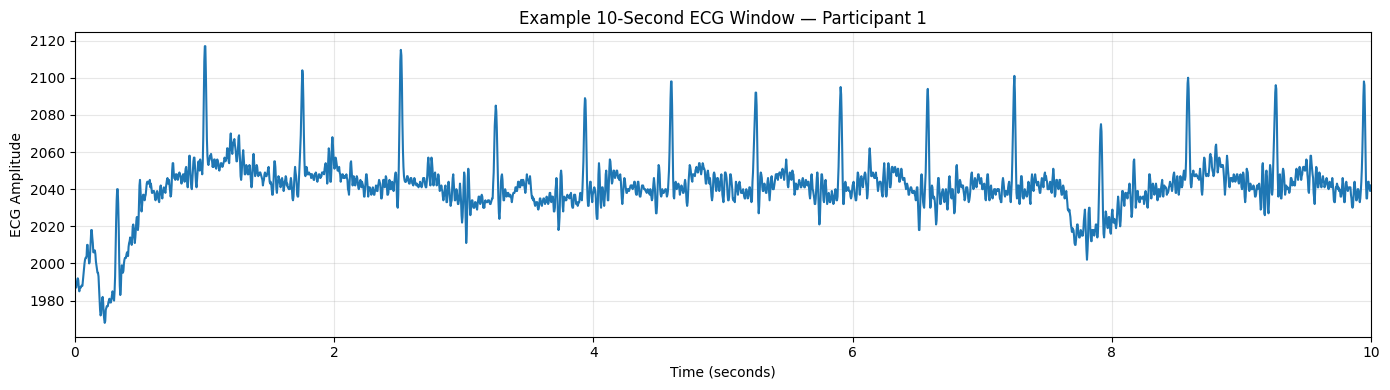


Waveform summary
----------------------------------------------------------------------
Participant:       1
WindowID:           389
Label:              1
Duration:           10.00 seconds
Samples:            2,500
ECG WAVEFORM VISUALISATION: COMPLETED


In [ ]:
# Cell 15 — Visualise Reconstructed ECG Window

import matplotlib.pyplot as plt

print("ECG Waveform Visualisation")
print("=" * 70)

# ------------------------------------------------------------
# Create time axis
# ------------------------------------------------------------

time_axis = (
    np.arange(len(sample_waveform))
    / SAMPLE_RATE
)

# ------------------------------------------------------------
# Plot waveform
# ------------------------------------------------------------

plt.figure(figsize=(14, 4))

plt.plot(
    time_axis,
    sample_waveform
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title(
    f"Example 10-Second ECG Window — "
    f"Participant {sample_metadata['ParticipantID']}"
)

plt.xlim(
    0,
    WINDOW_SECONDS
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# Display waveform information
# ------------------------------------------------------------

print("\nWaveform summary")
print("-" * 70)

print(
    f"Participant:       "
    f"{sample_metadata['ParticipantID']}"
)

print(
    f"WindowID:           "
    f"{sample_metadata['WindowID']}"
)

print(
    f"Label:              "
    f"{sample_metadata['WakeSleepLabel']}"
)

print(
    f"Duration:           "
    f"{len(sample_waveform) / SAMPLE_RATE:.2f} seconds"
)

print(
    f"Samples:            "
    f"{len(sample_waveform):,}"
)

print("=" * 70)
print("ECG WAVEFORM VISUALISATION: COMPLETED")
print("=" * 70)

In [ ]:
# Cell 16 — Build Disk-Backed ECG Waveform Cache

print("Building Disk-Backed ECG Waveform Cache")
print("=" * 70)

# ------------------------------------------------------------
# Cache directory
# ------------------------------------------------------------

CACHE_DIR = (
    "/content/drive/MyDrive/"
    "QMUL_MSc_Dissertation/"
    "Notebook4_Waveform_Cache"
)

os.makedirs(
    CACHE_DIR,
    exist_ok=True
)

print(f"Cache directory:\n{CACHE_DIR}")


# ------------------------------------------------------------
# Get only the ECG recordings required by Notebook 3
# ------------------------------------------------------------

required_ecg_paths = (
    dl_df["Path"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)

print(
    f"\nRequired ECG recordings: "
    f"{len(required_ecg_paths)}"
)


# ------------------------------------------------------------
# Build cache for each ECG recording
# ------------------------------------------------------------

cache_records = []

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as z:

    for i, ecg_path in enumerate(
        required_ecg_paths,
        start=1
    ):

        # Create a safe cache filename
        participant_id = (
            dl_df.loc[
                dl_df["Path"] == ecg_path,
                "ParticipantID"
            ]
            .iloc[0]
        )

        ecg_file = os.path.basename(
            ecg_path
        )

        cache_name = (
            f"{participant_id}_"
            f"{os.path.splitext(ecg_file)[0]}.npy"
        )

        cache_path = os.path.join(
            CACHE_DIR,
            cache_name
        )

        print(
            f"\n[{i}/{len(required_ecg_paths)}] "
            f"{participant_id} — {ecg_file}"
        )

        # ----------------------------------------------------
        # Use existing cache if already created
        # ----------------------------------------------------

        if os.path.exists(cache_path):

            cached_array = np.load(
                cache_path,
                mmap_mode="r"
            )

            print(
                f"  Existing cache found: "
                f"{cached_array.shape[0]:,} samples"
            )

            cache_records.append({
                "Path": ecg_path,
                "CachePath": cache_path,
                "NumSamples": len(cached_array)
            })

            continue


        # ----------------------------------------------------
        # Read only the ECG waveform column
        # ----------------------------------------------------

        with z.open(ecg_path) as f:

            ecg_data = pd.read_csv(
                f,
                usecols=["EcgWaveform"],
                dtype={
                    "EcgWaveform": "float32"
                }
            )


        waveform = (
            ecg_data["EcgWaveform"]
            .to_numpy(
                dtype=np.float32
            )
        )


        # ----------------------------------------------------
        # Validate waveform
        # ----------------------------------------------------

        if not np.isfinite(
            waveform
        ).all():

            raise ValueError(
                f"Non-finite ECG values found in:\n"
                f"{ecg_path}"
            )


        if len(waveform) == 0:

            raise ValueError(
                f"Empty ECG waveform:\n"
                f"{ecg_path}"
            )


        # ----------------------------------------------------
        # Save waveform as NumPy binary
        # ----------------------------------------------------

        np.save(
            cache_path,
            waveform
        )

        print(
            f"  Cached: "
            f"{len(waveform):,} samples"
        )

        cache_records.append({
            "Path": ecg_path,
            "CachePath": cache_path,
            "NumSamples": len(waveform)
        })

        # Free temporary dataframe/array
        del ecg_data
        del waveform


# ------------------------------------------------------------
# Create cache index
# ------------------------------------------------------------

waveform_cache_index = pd.DataFrame(
    cache_records
)

CACHE_INDEX_PATH = os.path.join(
    CACHE_DIR,
    "waveform_cache_index.csv"
)

waveform_cache_index.to_csv(
    CACHE_INDEX_PATH,
    index=False
)


# ------------------------------------------------------------
# Verify cache
# ------------------------------------------------------------

print("\n" + "=" * 70)

print(
    f"Cached ECG recordings: "
    f"{len(waveform_cache_index)}"
)

print(
    f"Cache index saved to:\n"
    f"{CACHE_INDEX_PATH}"
)

print(
    f"Total cached samples: "
    f"{waveform_cache_index['NumSamples'].sum():,}"
)

missing_cache_files = [
    path
    for path in waveform_cache_index["CachePath"]
    if not os.path.exists(path)
]

print(
    f"Missing cache files: "
    f"{len(missing_cache_files)}"
)


# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

cache_ready = (
    len(waveform_cache_index)
    == len(required_ecg_paths)
    and len(missing_cache_files) == 0
)

print(
    "\nWAVEFORM CACHE:",
    "READY" if cache_ready else "REQUIRES INVESTIGATION"
)

print("=" * 70)

Building Disk-Backed ECG Waveform Cache
Cache directory:
/content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook4_Waveform_Cache

Required ECG recordings: 34

[1/34] 1 — 2022_06_06__10_28_26_ECG.csv
  Existing cache found: 4,647,250 samples

[2/34] 1 — 2022_06_06__15_38_43_ECG.csv
  Existing cache found: 16,715,500 samples

[3/34] 1 — 2022_06_07__10_42_46_ECG.csv
  Existing cache found: 1,449,750 samples

[4/34] 2 — 2022_06_21__08_03_26_ECG.csv
  Existing cache found: 597,750 samples

[5/34] 2 — 2022_06_21__08_43_49_ECG.csv
  Existing cache found: 2,831,500 samples

[6/34] 2 — 2022_06_21__11_53_12_ECG.csv
  Existing cache found: 20,233,000 samples

[7/34] 3 — 2022_08_01__10_08_04_ECG.csv
  Existing cache found: 22,390,000 samples

[8/34] 4 — 2022_08_02__13_54_45_ECG.csv
  Existing cache found: 22,023,000 samples

[9/34] 5 — 2022_08_03__12_17_03_ECG.csv
  Existing cache found: 22,384,000 samples

[10/34] 6 — 2022_08_04__09_14_28_ECG.csv
  Existing cache found: 22,164,250 samples

[11/34] 

In [ ]:
# Cell 17 — Optimised ECG Batch Generator

import tensorflow as tf

print("Creating Optimised ECG Batch Generator")
print("=" * 70)

# ------------------------------------------------------------
# Build Path -> CachePath lookup
# ------------------------------------------------------------

cache_path_lookup = dict(
    zip(
        waveform_cache_index["Path"],
        waveform_cache_index["CachePath"]
    )
)

print(
    f"Cached ECG paths available: "
    f"{len(cache_path_lookup)}"
)


# ------------------------------------------------------------
# Open all required cached waveforms once
# ------------------------------------------------------------

waveform_memmaps = {}

for ecg_path, cache_path in cache_path_lookup.items():

    waveform_memmaps[ecg_path] = np.load(
        cache_path,
        mmap_mode="r"
    )

print(
    f"Memory-mapped ECG recordings: "
    f"{len(waveform_memmaps)}"
)


# ------------------------------------------------------------
# Optimised single-window loader
# ------------------------------------------------------------

def load_ecg_window_fast(row):
    """
    Load one ECG window using an already-open
    memory-mapped waveform.
    """

    ecg_path = row["Path"]

    waveform = waveform_memmaps.get(
        ecg_path
    )

    if waveform is None:
        raise FileNotFoundError(
            f"No memory-mapped waveform found for:\n"
            f"{ecg_path}"
        )

    start_sample = int(
        row["StartSample"]
    )

    end_sample = int(
        row["EndSample"]
    )

    window = np.asarray(
        waveform[
            start_sample:end_sample
        ],
        dtype=np.float32
    )

    if len(window) != WINDOW_SAMPLES:
        raise ValueError(
            f"Expected {WINDOW_SAMPLES} samples, "
            f"got {len(window)}"
        )

    if not np.isfinite(window).all():
        raise ValueError(
            "Non-finite ECG values detected."
        )

    # Per-window standardisation
    window_mean = window.mean()
    window_std = window.std()

    if window_std > 0:
        window = (
            window - window_mean
        ) / window_std
    else:
        window = (
            window - window_mean
        )

    return window


# ------------------------------------------------------------
# Optimised batch generator
# ------------------------------------------------------------

def generate_ecg_batches_fast(
    metadata_df,
    batch_size=64,
    shuffle=False
):
    """
    Efficient ECG batch generator.

    Output:
        X -> (batch_size, 2500, 1)
        y -> (batch_size,)
    """

    indices = np.arange(
        len(metadata_df)
    )

    rng = np.random.default_rng(
        SEED
    )

    while True:

        if shuffle:
            rng.shuffle(indices)

        for start in range(
            0,
            len(indices),
            batch_size
        ):

            batch_indices = indices[
                start:start + batch_size
            ]

            batch_rows = metadata_df.iloc[
                batch_indices
            ]

            batch_size_actual = len(
                batch_rows
            )

            X_batch = np.empty(
                (
                    batch_size_actual,
                    WINDOW_SAMPLES,
                    1
                ),
                dtype=np.float32
            )

            y_batch = (
                batch_rows[
                    "WakeSleepLabel"
                ]
                .to_numpy(
                    dtype=np.int32
                )
            )

            # Load each window
            for i, row in enumerate(
                batch_rows.itertuples(
                    index=False
                )
            ):

                # Access fields by column position
                path = row.Path
                start_sample = int(
                    row.StartSample
                )
                end_sample = int(
                    row.EndSample
                )

                waveform = waveform_memmaps[
                    path
                ]

                window = np.asarray(
                    waveform[
                        start_sample:end_sample
                    ],
                    dtype=np.float32
                )

                if len(window) != WINDOW_SAMPLES:
                    raise ValueError(
                        f"Invalid window length: "
                        f"{len(window)}"
                    )

                # Per-window standardisation
                window_mean = window.mean()
                window_std = window.std()

                if window_std > 0:
                    window = (
                        window - window_mean
                    ) / window_std
                else:
                    window = (
                        window - window_mean
                    )

                X_batch[
                    i,
                    :,
                    0
                ] = window

            yield X_batch, y_batch


# ------------------------------------------------------------
# Test the optimised generator
# ------------------------------------------------------------

TEST_BATCH_SIZE = 64

test_generator_fast = (
    generate_ecg_batches_fast(
        dl_train,
        batch_size=TEST_BATCH_SIZE,
        shuffle=False
    )
)

X_test_batch, y_test_batch = next(
    test_generator_fast
)


# ------------------------------------------------------------
# Validate batch
# ------------------------------------------------------------

print("\nOptimised test batch")
print("-" * 70)

print(
    f"X batch shape: "
    f"{X_test_batch.shape}"
)

print(
    f"y batch shape: "
    f"{y_test_batch.shape}"
)

print(
    f"X batch dtype: "
    f"{X_test_batch.dtype}"
)

print(
    f"X batch mean: "
    f"{X_test_batch.mean():.4f}"
)

print(
    f"X batch std: "
    f"{X_test_batch.std():.4f}"
)

print(
    f"Label distribution: "
    f"{np.bincount(y_test_batch)}"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

batch_shape_valid = (
    X_test_batch.shape
    == (
        TEST_BATCH_SIZE,
        WINDOW_SAMPLES,
        1
    )
)

batch_finite = np.isfinite(
    X_test_batch
).all()

labels_valid = set(
    np.unique(y_test_batch)
).issubset({0, 1})


print("\n" + "=" * 70)

print(
    "Batch shape:",
    "PASSED"
    if batch_shape_valid
    else "FAILED"
)

print(
    "Finite waveform values:",
    "PASSED"
    if batch_finite
    else "FAILED"
)

print(
    "Valid labels:",
    "PASSED"
    if labels_valid
    else "FAILED"
)

print(
    "OPTIMISED ECG GENERATOR:",
    "READY"
    if (
        batch_shape_valid
        and batch_finite
        and labels_valid
    )
    else "REQUIRES INVESTIGATION"
)

print("=" * 70)

Creating Optimised ECG Batch Generator
Cached ECG paths available: 34
Memory-mapped ECG recordings: 34

Optimised test batch
----------------------------------------------------------------------
X batch shape: (64, 2500, 1)
y batch shape: (64,)
X batch dtype: float32
X batch mean: 0.0000
X batch std: 1.0000
Label distribution: [ 0 64]

Batch shape: PASSED
Finite waveform values: PASSED
Valid labels: PASSED
OPTIMISED ECG GENERATOR: READY


## 7. Lightweight LSTM Development and Evaluation

The first deep-learning approach is a lightweight Long Short-Term Memory (LSTM) network operating on the full 2,500-sample ECG waveform.

The LSTM pathway consists of:

1. Hardware and input validation.
2. Lightweight model construction.
3. Training configuration and class weighting.
4. Model training with checkpointing and early stopping.
5. Validation-set evaluation.
6. Final test-set evaluation.

The LSTM is intentionally kept compact to investigate whether a recurrent architecture can provide useful classification performance while maintaining relatively low model complexity.

In [ ]:
# Cell 18 — Option A GPU and LSTM Diagnostic

print("Option A — Full-Resolution LSTM Diagnostic")
print("=" * 70)

# ------------------------------------------------------------
# 1. TensorFlow GPU detection
# ------------------------------------------------------------

print("\n1. TensorFlow GPU check")
print("-" * 70)

gpus = tf.config.list_physical_devices("GPU")

print(f"GPUs detected: {len(gpus)}")

for gpu in gpus:
    print(f"GPU: {gpu}")

if not gpus:
    raise RuntimeError(
        "NO GPU DETECTED. Do not start LSTM training."
    )

print("GPU detection: PASSED")


# ------------------------------------------------------------
# 2. Confirm full-resolution input
# ------------------------------------------------------------

print("\n2. Full-resolution ECG configuration")
print("-" * 70)

print(f"Sampling rate:     {SAMPLE_RATE} Hz")
print(f"Window duration:   {WINDOW_SECONDS} seconds")
print(f"Window samples:    {WINDOW_SAMPLES}")

if WINDOW_SAMPLES != 2500:
    raise ValueError(
        f"Expected 2500 samples, got {WINDOW_SAMPLES}"
    )

print("Full-resolution input: PASSED")


# ------------------------------------------------------------
# 3. Test full-resolution batch
# ------------------------------------------------------------

print("\n3. Full-resolution batch verification")
print("-" * 70)

option_a_generator = generate_ecg_batches_fast(
    dl_train,
    batch_size=64,
    shuffle=False
)

X_option_a, y_option_a = next(
    option_a_generator
)

print(
    f"X shape: {X_option_a.shape}"
)

print(
    f"y shape: {y_option_a.shape}"
)

print(
    f"X dtype: {X_option_a.dtype}"
)

print(
    f"X mean: {X_option_a.mean():.4f}"
)

print(
    f"X std: {X_option_a.std():.4f}"
)

if X_option_a.shape != (64, 2500, 1):
    raise ValueError(
        f"Unexpected shape: {X_option_a.shape}"
    )

if not np.isfinite(X_option_a).all():
    raise ValueError(
        "Non-finite values detected."
    )

print("Full-resolution batch: PASSED")


# ------------------------------------------------------------
# 4. Short data-pipeline speed test
# ------------------------------------------------------------

print("\n4. Full-resolution pipeline speed test")
print("-" * 70)

DIAGNOSTIC_BATCHES = 100

diagnostic_generator = generate_ecg_batches_fast(
    dl_train,
    batch_size=64,
    shuffle=False
)

diagnostic_start = time.time()

for _ in range(DIAGNOSTIC_BATCHES):
    X_diag, y_diag = next(
        diagnostic_generator
    )

diagnostic_time = (
    time.time() - diagnostic_start
)

seconds_per_batch = (
    diagnostic_time / DIAGNOSTIC_BATCHES
)

estimated_epoch_minutes = (
    LSTM_STEPS_PER_EPOCH
    * seconds_per_batch
    / 60
    if "LSTM_STEPS_PER_EPOCH" in globals()
    else None
)

print(
    f"Diagnostic batches:       {DIAGNOSTIC_BATCHES}"
)

print(
    f"Total time:                "
    f"{diagnostic_time:.2f} seconds"
)

print(
    f"Time per batch:            "
    f"{seconds_per_batch:.4f} seconds"
)

if estimated_epoch_minutes is not None:
    print(
        f"Estimated data time/epoch: "
        f"{estimated_epoch_minutes:.2f} minutes"
    )


# ------------------------------------------------------------
# 5. Diagnostic summary
# ------------------------------------------------------------

print("\n" + "=" * 70)

print("OPTION A DIAGNOSTIC: READY")

print("=" * 70)

Option A — Full-Resolution LSTM Diagnostic

1. TensorFlow GPU check
----------------------------------------------------------------------
GPUs detected: 1
GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU detection: PASSED

2. Full-resolution ECG configuration
----------------------------------------------------------------------
Sampling rate:     250 Hz
Window duration:   10 seconds
Window samples:    2500
Full-resolution input: PASSED

3. Full-resolution batch verification
----------------------------------------------------------------------
X shape: (64, 2500, 1)
y shape: (64,)
X dtype: float32
X mean: 0.0000
X std: 1.0000
Full-resolution batch: PASSED

4. Full-resolution pipeline speed test
----------------------------------------------------------------------
Diagnostic batches:       100
Total time:                1.19 seconds
Time per batch:            0.0119 seconds

OPTION A DIAGNOSTIC: READY


In [ ]:
# Cell 19 — Build Full-Resolution Lightweight LSTM

print("Building Full-Resolution Lightweight LSTM")
print("=" * 70)

# ------------------------------------------------------------
# Full-resolution LSTM architecture
# ------------------------------------------------------------

LSTM_INPUT_SAMPLES = 2500
LSTM_UNITS = 32
LSTM_DENSE_UNITS = 16
LSTM_DROPOUT = 0.30

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(LSTM_INPUT_SAMPLES, 1)
    ),

    tf.keras.layers.LSTM(
        LSTM_UNITS,
        activation="tanh",
        recurrent_activation="sigmoid",
        recurrent_dropout=0.0,
        return_sequences=False
    ),

    tf.keras.layers.Dense(
        LSTM_DENSE_UNITS,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        LSTM_DROPOUT
    ),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ------------------------------------------------------------
# Checkpoint directory
# ------------------------------------------------------------

LSTM_CHECKPOINT_DIR = (
    "/content/drive/MyDrive/"
    "QMUL_MSc_Dissertation/"
    "Notebook4_LSTM_Checkpoints"
)

os.makedirs(
    LSTM_CHECKPOINT_DIR,
    exist_ok=True
)

LSTM_CHECKPOINT_PATH = os.path.join(
    LSTM_CHECKPOINT_DIR,
    "lstm_option_a_best.weights.h5"
)

# ------------------------------------------------------------
# Model information
# ------------------------------------------------------------

print("\nModel summary")
print("-" * 70)

lstm_model.summary()

print("\nModel information")
print("-" * 70)

print(
    f"LSTM input shape: "
    f"{lstm_model.input_shape}"
)

print(
    f"LSTM trainable parameters: "
    f"{lstm_model.count_params():,}"
)

print(
    f"Checkpoint path: "
    f"{LSTM_CHECKPOINT_PATH}"
)

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

assert lstm_model.input_shape == (None, 2500, 1)
assert lstm_model.count_params() == 4897

print("\n" + "=" * 70)
print("FULL-RESOLUTION LSTM ARCHITECTURE: READY")
print("=" * 70)

Building Full-Resolution Lightweight LSTM

Model summary
----------------------------------------------------------------------


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,897 (19.13 KB)

 Trainable params: 4,897 (19.13 KB)

 Non-trainable params: 0 (0.00 B)


Model information
----------------------------------------------------------------------
LSTM input shape: (None, 2500, 1)
LSTM trainable parameters: 4,897
Checkpoint path: /content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook4_LSTM_Checkpoints/lstm_option_a_best.weights.h5

FULL-RESOLUTION LSTM ARCHITECTURE: READY


In [ ]:
# Cell 20 — Option A LSTM Training Configuration

print("LSTM Training Configuration — Option A")
print("=" * 70)

# ------------------------------------------------------------
# Training parameters
# ------------------------------------------------------------

LSTM_BATCH_SIZE = 64
LSTM_EPOCHS = 15

LSTM_STEPS_PER_EPOCH = len(dl_train) // LSTM_BATCH_SIZE
LSTM_VALIDATION_STEPS = len(dl_validation) // LSTM_BATCH_SIZE

print("\nTraining parameters")
print("-" * 70)

print(f"Input samples per window: {LSTM_INPUT_SAMPLES:,}")
print(f"Batch size:              {LSTM_BATCH_SIZE}")
print(f"Maximum epochs:          {LSTM_EPOCHS}")
print(f"Training windows:        {len(dl_train):,}")
print(f"Validation windows:      {len(dl_validation):,}")
print(f"Steps per epoch:         {LSTM_STEPS_PER_EPOCH:,}")
print(f"Validation steps:        {LSTM_VALIDATION_STEPS:,}")


# ------------------------------------------------------------
# Class weighting
# ------------------------------------------------------------
# Training distribution from the validated participant-level split

LSTM_CLASS_WEIGHTS = {
    0: 2.3905,   # Sleep
    1: 0.6322    # Wake
}

print("\nClass weights")
print("-" * 70)

print(f"Sleep (0): {LSTM_CLASS_WEIGHTS[0]:.4f}")
print(f"Wake  (1): {LSTM_CLASS_WEIGHTS[1]:.4f}")


# ------------------------------------------------------------
# Checkpointing
# ------------------------------------------------------------

lstm_best_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=LSTM_CHECKPOINT_PATH,
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)


# ------------------------------------------------------------
# Early stopping
# ------------------------------------------------------------

lstm_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# ------------------------------------------------------------
# Learning-rate reduction
# ------------------------------------------------------------

lstm_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)


# ------------------------------------------------------------
# Training generators
# ------------------------------------------------------------

lstm_train_generator = generate_ecg_batches_fast(
    dl_train,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=True
)

lstm_validation_generator = generate_ecg_batches_fast(
    dl_validation,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=False
)


# ------------------------------------------------------------
# Final configuration summary
# ------------------------------------------------------------

print("\nCallbacks")
print("-" * 70)

print("Model checkpoint:        monitor=val_auc, save_best_only=True")
print("Early stopping:          monitor=val_auc, patience=3")
print("Learning-rate reduction: monitor=val_auc, factor=0.5")

print("\n" + "=" * 70)
print("OPTION A LSTM TRAINING CONFIGURATION: READY")
print("=" * 70)

LSTM Training Configuration — Option A

Training parameters
----------------------------------------------------------------------
Input samples per window: 2,500
Batch size:              64
Maximum epochs:          15
Training windows:        297,867
Validation windows:      57,718
Steps per epoch:         4,654
Validation steps:        901

Class weights
----------------------------------------------------------------------
Sleep (0): 2.3905
Wake  (1): 0.6322

Callbacks
----------------------------------------------------------------------
Model checkpoint:        monitor=val_auc, save_best_only=True
Early stopping:          monitor=val_auc, patience=3
Learning-rate reduction: monitor=val_auc, factor=0.5

OPTION A LSTM TRAINING CONFIGURATION: READY


In [ ]:
# Cell 21 — Train Option A LSTM — Fixed Class Weight Handling

print("\n" + "=" * 70)
print("TRAINING OPTION A — FULL-RESOLUTION LIGHTWEIGHT LSTM")
print("=" * 70)

import os
import time
import numpy as np
import tensorflow as tf


# ============================================================
# 1. GPU CHECK
# ============================================================

print("\nHardware check")
print("-" * 70)

gpus = tf.config.list_physical_devices("GPU")

print(f"GPUs detected: {len(gpus)}")

if len(gpus) == 0:
    raise RuntimeError(
        "NO GPU DETECTED. Training has NOT started."
    )

print(f"GPU: {gpus[0].name}")
print("GPU detection: PASSED")


# ============================================================
# 2. FULL-RESOLUTION CHECK
# ============================================================

print("\nFull-resolution input check")
print("-" * 70)

print(f"Input samples: {LSTM_INPUT_SAMPLES}")
print(f"Expected shape: (None, 2500, 1)")

if LSTM_INPUT_SAMPLES != 2500:
    raise ValueError(
        f"Option A requires 2500 samples, "
        f"but received {LSTM_INPUT_SAMPLES}"
    )

print("Full-resolution input: PASSED")




print("\nCreating weighted LSTM training generator")
print("-" * 70)

def generate_lstm_batches_with_weights(
    metadata_df,
    batch_size=64,
    shuffle=False
):
    """
    Full-resolution ECG generator for LSTM training.

    Returns:
        X_batch
        y_batch
        sample_weights

    This is equivalent to using class_weight in Keras,
    but is compatible with Python generators.
    """

    base_generator = generate_ecg_batches_fast(
        metadata_df,
        batch_size=batch_size,
        shuffle=shuffle
    )

    while True:

        X_batch, y_batch = next(base_generator)

        sample_weights = np.where(
            y_batch == 0,
            LSTM_CLASS_WEIGHTS[0],
            LSTM_CLASS_WEIGHTS[1]
        ).astype(np.float32)

        yield (
            X_batch,
            y_batch,
            sample_weights
        )


# ------------------------------------------------------------
# Create generators
# ------------------------------------------------------------

lstm_train_generator_weighted = (
    generate_lstm_batches_with_weights(
        dl_train,
        batch_size=LSTM_BATCH_SIZE,
        shuffle=True
    )
)

lstm_validation_generator = (
    generate_ecg_batches_fast(
        dl_validation,
        batch_size=LSTM_BATCH_SIZE,
        shuffle=False
    )
)


# ============================================================
# 4. VERIFY WEIGHTED BATCH BEFORE TRAINING
# ============================================================

X_check, y_check, weights_check = next(
    lstm_train_generator_weighted
)

print("\nWeighted batch verification")
print("-" * 70)

print(f"X shape:       {X_check.shape}")
print(f"y shape:       {y_check.shape}")
print(f"weights shape: {weights_check.shape}")

print(
    f"Unique labels: {np.unique(y_check)}"
)

print(
    f"Unique weights: {np.unique(weights_check)}"
)

if X_check.shape != (64, 2500, 1):
    raise ValueError(
        f"Unexpected X shape: {X_check.shape}"
    )

if y_check.shape != (64,):
    raise ValueError(
        f"Unexpected y shape: {y_check.shape}"
    )

if weights_check.shape != (64,):
    raise ValueError(
        f"Unexpected weights shape: {weights_check.shape}"
    )

if not np.isfinite(X_check).all():
    raise ValueError(
        "Non-finite ECG values detected."
    )

print("Weighted batch: PASSED")


# ============================================================
# 5. TRAIN
# ============================================================

print("\n" + "=" * 70)
print("STARTING OPTION A LSTM TRAINING")
print("=" * 70)

print(f"\nInput samples/window: {LSTM_INPUT_SAMPLES:,}")
print(f"Batch size:           {LSTM_BATCH_SIZE}")
print(f"Maximum epochs:       {LSTM_EPOCHS}")
print(f"Training steps/epoch: {LSTM_STEPS_PER_EPOCH:,}")
print(f"Validation steps:     {LSTM_VALIDATION_STEPS:,}")

print("\nClass weights:")
print(f"  Sleep (0): {LSTM_CLASS_WEIGHTS[0]:.4f}")
print(f"  Wake  (1): {LSTM_CLASS_WEIGHTS[1]:.4f}")

print("\nEarly stopping: patience = 3")
print("Checkpointing: ENABLED")
print("\nTraining now...\n")

lstm_training_start = time.time()

try:

    lstm_history = lstm_model.fit(
        lstm_train_generator_weighted,
        steps_per_epoch=LSTM_STEPS_PER_EPOCH,

        validation_data=lstm_validation_generator,
        validation_steps=LSTM_VALIDATION_STEPS,

        epochs=LSTM_EPOCHS,

        callbacks=[
            lstm_best_checkpoint,
            lstm_early_stopping,
            lstm_reduce_lr
        ],

        verbose=1
    )

except Exception as e:

    elapsed = (
        time.time() - lstm_training_start
    ) / 60

    print("\n" + "=" * 70)
    print("OPTION A TRAINING INTERRUPTED")
    print("=" * 70)

    print(f"Elapsed time: {elapsed:.2f} minutes")
    print(f"Error type: {type(e).__name__}")
    print(f"Error: {e}")

    print("\nCheckpoint location:")
    print(LSTM_CHECKPOINT_PATH)

    raise


# ============================================================
# 6. TRAINING SUMMARY
# ============================================================

lstm_training_time = (
    time.time() - lstm_training_start
)

epochs_completed = len(
    lstm_history.history["loss"]
)

print("\n" + "=" * 70)
print("OPTION A LSTM TRAINING COMPLETED")
print("=" * 70)

print(
    f"Total training time: "
    f"{lstm_training_time / 60:.2f} minutes"
)

print(
    f"Epochs completed: "
    f"{epochs_completed}"
)

print(
    f"Best checkpoint: "
    f"{LSTM_CHECKPOINT_PATH}"
)

if "val_auc" in lstm_history.history:

    best_epoch = (
        int(
            np.argmax(
                lstm_history.history["val_auc"]
            )
        ) + 1
    )

    best_val_auc = max(
        lstm_history.history["val_auc"]
    )

    print(
        f"Best validation epoch: "
        f"{best_epoch}"
    )

    print(
        f"Best validation ROC-AUC: "
        f"{best_val_auc:.4f}"
    )

print("\nOPTION A LSTM TRAINING: COMPLETED")
print("=" * 70)


TRAINING OPTION A — FULL-RESOLUTION LIGHTWEIGHT LSTM

Hardware check
----------------------------------------------------------------------
GPUs detected: 1
GPU: /physical_device:GPU:0
GPU detection: PASSED

Full-resolution input check
----------------------------------------------------------------------
Input samples: 2500
Expected shape: (None, 2500, 1)
Full-resolution input: PASSED

Creating weighted LSTM training generator
----------------------------------------------------------------------

Weighted batch verification
----------------------------------------------------------------------
X shape:       (64, 2500, 1)
y shape:       (64,)
weights shape: (64,)
Unique labels: [0 1]
Unique weights: [0.6322 2.3905]
Weighted batch: PASSED

STARTING OPTION A LSTM TRAINING

Input samples/window: 2,500
Batch size:           64
Maximum epochs:       15
Training steps/epoch: 4,654
Validation steps:     901

Class weights:
  Sleep (0): 2.3905
  Wake  (1): 0.6322

Early stopping: patience =

In [ ]:
# Cell 22 — Option A LSTM Validation Evaluation

print("Option A LSTM Validation Evaluation")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load the BEST Option A checkpoint
# ------------------------------------------------------------

print("\nLoading best Option A LSTM checkpoint")
print("-" * 70)

lstm_model.load_weights(
    LSTM_CHECKPOINT_PATH
)

print(
    f"Checkpoint loaded: "
    f"{LSTM_CHECKPOINT_PATH}"
)

# ------------------------------------------------------------
# 2. Get validation labels directly from DL metadata
# ------------------------------------------------------------

lstm_y_validation = (
    dl_validation["WakeSleepLabel"]
    .to_numpy(dtype=np.int32)
)

print("\nValidation label check")
print("-" * 70)

print(
    f"Validation windows: "
    f"{len(lstm_y_validation):,}"
)

print(
    f"Unique labels: "
    f"{np.unique(lstm_y_validation)}"
)

# ------------------------------------------------------------
# 3. Create a FRESH validation generator
# ------------------------------------------------------------

lstm_eval_generator = (
    generate_ecg_batches_fast(
        dl_validation,
        batch_size=LSTM_BATCH_SIZE,
        shuffle=False
    )
)

# ------------------------------------------------------------
# 4. Generate validation predictions
# ------------------------------------------------------------

print("\nGenerating validation predictions")
print("-" * 70)

lstm_prediction_start = time.time()

lstm_validation_probabilities = (
    lstm_model.predict(
        lstm_eval_generator,
        steps=int(
            np.ceil(
                len(dl_validation)
                / LSTM_BATCH_SIZE
            )
        ),
        verbose=1
    )
)

lstm_prediction_time = (
    time.time() - lstm_prediction_start
)

# ------------------------------------------------------------
# 5. Convert probabilities to binary predictions
# ------------------------------------------------------------

lstm_validation_probabilities = (
    lstm_validation_probabilities
    .reshape(-1)
)

# Keep exactly the number of validation windows
lstm_validation_probabilities = (
    lstm_validation_probabilities[
        :len(lstm_y_validation)
    ]
)

lstm_validation_pred = (
    lstm_validation_probabilities >= 0.5
).astype(int)

# ------------------------------------------------------------
# 6. Verify prediction dimensions
# ------------------------------------------------------------

if len(lstm_validation_pred) != len(lstm_y_validation):

    raise ValueError(
        f"Prediction/label mismatch: "
        f"{len(lstm_validation_pred)} predictions "
        f"vs "
        f"{len(lstm_y_validation)} labels"
    )

# ------------------------------------------------------------
# 7. Calculate validation metrics
# ------------------------------------------------------------

lstm_validation_accuracy = accuracy_score(
    lstm_y_validation,
    lstm_validation_pred
)

lstm_validation_precision = precision_score(
    lstm_y_validation,
    lstm_validation_pred,
    zero_division=0
)

lstm_validation_recall = recall_score(
    lstm_y_validation,
    lstm_validation_pred,
    zero_division=0
)

lstm_validation_f1 = f1_score(
    lstm_y_validation,
    lstm_validation_pred,
    zero_division=0
)

lstm_validation_auc = roc_auc_score(
    lstm_y_validation,
    lstm_validation_probabilities
)

lstm_validation_cm = confusion_matrix(
    lstm_y_validation,
    lstm_validation_pred
)

# ------------------------------------------------------------
# 8. Display validation performance
# ------------------------------------------------------------

print("\nValidation Performance")
print("-" * 70)

print(
    f"Accuracy:        "
    f"{lstm_validation_accuracy:.4f}"
)

print(
    f"Precision:       "
    f"{lstm_validation_precision:.4f}"
)

print(
    f"Recall:          "
    f"{lstm_validation_recall:.4f}"
)

print(
    f"F1-score:        "
    f"{lstm_validation_f1:.4f}"
)

print(
    f"ROC-AUC:         "
    f"{lstm_validation_auc:.4f}"
)

print(
    f"Prediction time: "
    f"{lstm_prediction_time:.2f} seconds"
)

print(
    f"Predictions:     "
    f"{len(lstm_validation_pred):,}"
)

# ------------------------------------------------------------
# 9. Validation confusion matrix
# ------------------------------------------------------------

print("\nValidation Confusion Matrix")
print("-" * 70)

print(
    pd.DataFrame(
        lstm_validation_cm,
        index=[
            "Actual Sleep",
            "Actual Wake"
        ],
        columns=[
            "Predicted Sleep",
            "Predicted Wake"
        ]
    )
)

# ------------------------------------------------------------
# 10. Model information
# ------------------------------------------------------------

print("\nModel Information")
print("-" * 70)

print(
    f"Trainable parameters: "
    f"{lstm_model.count_params():,}"
)

if (
    "lstm_history" in globals()
    and "val_auc" in lstm_history.history
):

    best_training_epoch = (
        np.argmax(
            lstm_history.history["val_auc"]
        ) + 1
    )

    best_training_val_auc = max(
        lstm_history.history["val_auc"]
    )

    print(
        f"Best training epoch: "
        f"{best_training_epoch}"
    )

    print(
        f"Best training validation ROC-AUC: "
        f"{best_training_val_auc:.4f}"
    )

# ------------------------------------------------------------
# 11. Final validation check
# ------------------------------------------------------------

lstm_evaluation_complete = (
    len(lstm_validation_pred)
    == len(lstm_y_validation)
    and np.isfinite(
        lstm_validation_probabilities
    ).all()
)

print("\n" + "=" * 70)

print(
    "OPTION A LSTM VALIDATION EVALUATION:",
    "PASSED"
    if lstm_evaluation_complete
    else "FAILED"
)

print("=" * 70)

Option A LSTM Validation Evaluation

Loading best Option A LSTM checkpoint
----------------------------------------------------------------------
Checkpoint loaded: /content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook4_LSTM_Checkpoints/lstm_option_a_best.weights.h5

Validation label check
----------------------------------------------------------------------
Validation windows: 57,718
Unique labels: [0 1]

Generating validation predictions
----------------------------------------------------------------------
902/902 ━━━━━━━━━━━━━━━━━━━━ 34s 38ms/step

Validation Performance
----------------------------------------------------------------------
Accuracy:        0.4159
Precision:       0.8604
Recall:          0.3471
F1-score:        0.4947
ROC-AUC:         0.5695
Prediction time: 34.81 seconds
Predictions:     57,718

Validation Confusion Matrix
----------------------------------------------------------------------
              Predicted Sleep  Predicted Wake
Actual Sleep             

In [ ]:
# Cell 23 — Option A LSTM Test Evaluation

print("=" * 70)
print("OPTION A LSTM TEST EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load the best Option A LSTM checkpoint
# ------------------------------------------------------------

print("\nLoading best Option A LSTM checkpoint")
print("-" * 70)

lstm_model.load_weights(LSTM_CHECKPOINT_PATH)

print(f"Checkpoint loaded: {LSTM_CHECKPOINT_PATH}")

# ------------------------------------------------------------
# 2. Test labels
# ------------------------------------------------------------

lstm_y_test = dl_test["WakeSleepLabel"].to_numpy(dtype=np.int32)

print("\nTest dataset check")
print("-" * 70)

print(f"Test windows: {len(lstm_y_test):,}")
print(f"Unique labels: {np.unique(lstm_y_test)}")

# ------------------------------------------------------------
# 3. Fresh test generator
# ------------------------------------------------------------

lstm_test_generator = generate_ecg_batches_fast(
    dl_test,
    batch_size=LSTM_BATCH_SIZE,
    shuffle=False
)

# ------------------------------------------------------------
# 4. Generate test predictions
# ------------------------------------------------------------

print("\nGenerating test predictions")
print("-" * 70)

lstm_test_start = time.time()

lstm_test_probabilities = lstm_model.predict(
    lstm_test_generator,
    steps=int(np.ceil(len(dl_test) / LSTM_BATCH_SIZE)),
    verbose=1
)

lstm_test_prediction_time = time.time() - lstm_test_start

# ------------------------------------------------------------
# 5. Prepare predictions
# ------------------------------------------------------------

lstm_test_probabilities = np.asarray(
    lstm_test_probabilities
).reshape(-1)

lstm_test_probabilities = (
    lstm_test_probabilities[:len(lstm_y_test)]
)

lstm_test_predictions = (
    lstm_test_probabilities >= 0.5
).astype(int)

# ------------------------------------------------------------
# 6. Verify alignment
# ------------------------------------------------------------

if len(lstm_test_predictions) != len(lstm_y_test):
    raise ValueError(
        f"Prediction/label mismatch: "
        f"{len(lstm_test_predictions)} predictions vs "
        f"{len(lstm_y_test)} labels"
    )

# ------------------------------------------------------------
# 7. Calculate test metrics
# ------------------------------------------------------------

lstm_test_accuracy = accuracy_score(
    lstm_y_test,
    lstm_test_predictions
)

lstm_test_precision = precision_score(
    lstm_y_test,
    lstm_test_predictions,
    zero_division=0
)

lstm_test_recall = recall_score(
    lstm_y_test,
    lstm_test_predictions,
    zero_division=0
)

lstm_test_f1 = f1_score(
    lstm_y_test,
    lstm_test_predictions,
    zero_division=0
)

lstm_test_auc = roc_auc_score(
    lstm_y_test,
    lstm_test_probabilities
)

lstm_test_cm = confusion_matrix(
    lstm_y_test,
    lstm_test_predictions
)

# ------------------------------------------------------------
# 8. Display test performance
# ------------------------------------------------------------

print("\nTest Performance")
print("-" * 70)

print(f"Accuracy:        {lstm_test_accuracy:.4f}")
print(f"Precision:       {lstm_test_precision:.4f}")
print(f"Recall:          {lstm_test_recall:.4f}")
print(f"F1-score:        {lstm_test_f1:.4f}")
print(f"ROC-AUC:         {lstm_test_auc:.4f}")
print(f"Prediction time: {lstm_test_prediction_time:.2f} seconds")
print(f"Predictions:     {len(lstm_test_predictions):,}")

# ------------------------------------------------------------
# 9. Test confusion matrix
# ------------------------------------------------------------

print("\nTest Confusion Matrix")
print("-" * 70)

print(
    pd.DataFrame(
        lstm_test_cm,
        index=["Actual Sleep", "Actual Wake"],
        columns=["Predicted Sleep", "Predicted Wake"]
    )
)

# ------------------------------------------------------------
# 10. Model information
# ------------------------------------------------------------

print("\nModel Information")
print("-" * 70)

print(f"Input samples/window: {WINDOW_SAMPLES:,}")
print(f"Trainable parameters: {lstm_model.count_params():,}")

best_epoch = (
    np.argmax(lstm_history.history["val_auc"]) + 1
)

best_val_auc = max(
    lstm_history.history["val_auc"]
)

print(f"Best training epoch: {best_epoch}")
print(f"Best validation ROC-AUC: {best_val_auc:.4f}")

# ------------------------------------------------------------
# 11. Final check
# ------------------------------------------------------------

lstm_test_evaluation_complete = (
    len(lstm_test_predictions) == len(lstm_y_test)
    and np.isfinite(lstm_test_probabilities).all()
)

print("\n" + "=" * 70)

if lstm_test_evaluation_complete:
    print("OPTION A LSTM TEST EVALUATION: PASSED")
else:
    print("OPTION A LSTM TEST EVALUATION: FAILED")

print("=" * 70)

OPTION A LSTM TEST EVALUATION

Loading best Option A LSTM checkpoint
----------------------------------------------------------------------
Checkpoint loaded: /content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook4_LSTM_Checkpoints/lstm_option_a_best.weights.h5

Test dataset check
----------------------------------------------------------------------
Test windows: 65,581
Unique labels: [0 1]

Generating test predictions
----------------------------------------------------------------------
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 41s 40ms/step

Test Performance
----------------------------------------------------------------------
Accuracy:        0.4084
Precision:       0.8022
Recall:          0.3107
F1-score:        0.4479
ROC-AUC:         0.5498
Prediction time: 42.01 seconds
Predictions:     65,581

Test Confusion Matrix
----------------------------------------------------------------------
              Predicted Sleep  Predicted Wake
Actual Sleep            11043            3880
Actual Wake

## 8. Lightweight CNN Development and Evaluation

A lightweight one-dimensional Convolutional Neural Network (CNN) is developed as the second deep-learning approach.

The CNN operates directly on the 2,500-sample ECG waveform and uses a compact convolutional architecture followed by pooling and fully connected layers.

The CNN is trained and evaluated using the same participant-level data split and evaluation methodology used for the LSTM. This allows its predictive performance and computational requirements to be compared consistently with both the LSTM and traditional ML baselines.

In [ ]:
# Cell 24 — Build Lightweight 1D CNN

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    MaxPooling1D,
    GlobalAveragePooling1D,
    Dense,
    Dropout
)

print("=" * 70)
print("BUILDING LIGHTWEIGHT 1D CNN")
print("=" * 70)

# ------------------------------------------------------------
# CNN configuration
# ------------------------------------------------------------

CNN_INPUT_SAMPLES = 2500
CNN_BATCH_SIZE = 64
CNN_EPOCHS = 15
CNN_STEPS_PER_EPOCH = int(
    np.ceil(len(dl_train) / CNN_BATCH_SIZE)
)
CNN_VALIDATION_STEPS = int(
    np.ceil(len(dl_validation) / CNN_BATCH_SIZE)
)

CNN_CLASS_WEIGHTS = {
    0: 2.3905,   # Sleep
    1: 0.6322    # Wake
}

print("\nCNN configuration")
print("-" * 70)

print(f"Input samples/window: {CNN_INPUT_SAMPLES:,}")
print(f"Batch size:           {CNN_BATCH_SIZE}")
print(f"Maximum epochs:       {CNN_EPOCHS}")
print(f"Training steps/epoch: {CNN_STEPS_PER_EPOCH:,}")
print(f"Validation steps:     {CNN_VALIDATION_STEPS:,}")

# ------------------------------------------------------------
# Build CNN
# ------------------------------------------------------------

cnn_model = Sequential([
    Input(
        shape=(CNN_INPUT_SAMPLES, 1)
    ),

    Conv1D(
        filters=16,
        kernel_size=7,
        activation="relu",
        padding="same"
    ),

    MaxPooling1D(
        pool_size=2
    ),

    Conv1D(
        filters=32,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    GlobalAveragePooling1D(),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(
        0.3
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(
            name="auc"
        ),
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

# ------------------------------------------------------------
# Display architecture
# ------------------------------------------------------------

print("\nCNN model summary")
print("-" * 70)

cnn_model.summary()

print("\nModel information")
print("-" * 70)

print(
    f"CNN trainable parameters: "
    f"{cnn_model.count_params():,}"
)

print(
    f"CNN input shape: "
    f"{cnn_model.input_shape}"
)

# ------------------------------------------------------------
# Verify expected lightweight architecture
# ------------------------------------------------------------

if cnn_model.count_params() != 3809:
    print(
        f"\nWARNING: Expected approximately 3,809 "
        f"parameters, got {cnn_model.count_params():,}"
    )
else:
    print(
        "\nCNN parameter count: 3,809"
    )

if cnn_model.input_shape == (
    None,
    CNN_INPUT_SAMPLES,
    1
):
    print(
        "CNN input shape: PASSED"
    )
else:
    raise ValueError(
        f"Unexpected CNN input shape: "
        f"{cnn_model.input_shape}"
    )

print("\n" + "=" * 70)
print("LIGHTWEIGHT CNN ARCHITECTURE: READY")
print("=" * 70)

BUILDING LIGHTWEIGHT 1D CNN

CNN configuration
----------------------------------------------------------------------
Input samples/window: 2,500
Batch size:           64
Maximum epochs:       15
Training steps/epoch: 4,655
Validation steps:     902

CNN model summary
----------------------------------------------------------------------


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2500, 16)       │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1250, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1250, 32)       │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,809 (14.88 KB)

 Trainable params: 3,809 (14.88 KB)

 Non-trainable params: 0 (0.00 B)


Model information
----------------------------------------------------------------------
CNN trainable parameters: 3,809
CNN input shape: (None, 2500, 1)

CNN parameter count: 3,809
CNN input shape: PASSED

LIGHTWEIGHT CNN ARCHITECTURE: READY


In [ ]:
# Cell 25 — Train Lightweight CNN

import os
import time
import tensorflow as tf

print("=" * 70)
print("TRAINING LIGHTWEIGHT 1D CNN")
print("=" * 70)

# ------------------------------------------------------------
# CNN training configuration
# ------------------------------------------------------------

CNN_BATCH_SIZE = 64
CNN_EPOCHS = 15

CNN_STEPS_PER_EPOCH = int(
    np.ceil(len(dl_train) / CNN_BATCH_SIZE)
)

CNN_VALIDATION_STEPS = int(
    np.ceil(len(dl_validation) / CNN_BATCH_SIZE)
)

CNN_CLASS_WEIGHTS = {
    0: 2.3905,   # Sleep
    1: 0.6322    # Wake
}

print("\nTraining parameters")
print("-" * 70)

print(f"Input samples/window:  {CNN_INPUT_SAMPLES:,}")
print(f"Batch size:             {CNN_BATCH_SIZE}")
print(f"Maximum epochs:         {CNN_EPOCHS}")
print(f"Training windows:       {len(dl_train):,}")
print(f"Validation windows:     {len(dl_validation):,}")
print(f"Steps per epoch:        {CNN_STEPS_PER_EPOCH:,}")
print(f"Validation steps:       {CNN_VALIDATION_STEPS:,}")

# ------------------------------------------------------------
# Create weighted training generator
# ------------------------------------------------------------

def generate_cnn_batches_with_weights(
    metadata_df,
    batch_size=64,
    shuffle=False
):
    """
    Generate ECG batches with sample weights
    for class-imbalanced CNN training.
    """

    base_generator = generate_ecg_batches_fast(
        metadata_df,
        batch_size=batch_size,
        shuffle=shuffle
    )

    while True:

        X_batch, y_batch = next(base_generator)

        sample_weights = np.where(
            y_batch == 0,
            CNN_CLASS_WEIGHTS[0],
            CNN_CLASS_WEIGHTS[1]
        ).astype(np.float32)

        yield (
            X_batch,
            y_batch,
            sample_weights
        )


cnn_train_generator = generate_cnn_batches_with_weights(
    dl_train,
    batch_size=CNN_BATCH_SIZE,
    shuffle=True
)

cnn_validation_generator = generate_ecg_batches_fast(
    dl_validation,
    batch_size=CNN_BATCH_SIZE,
    shuffle=False
)

# ------------------------------------------------------------
# Verify one weighted batch
# ------------------------------------------------------------

X_cnn_check, y_cnn_check, w_cnn_check = next(
    cnn_train_generator
)

print("\nCNN batch verification")
print("-" * 70)

print(f"X shape:       {X_cnn_check.shape}")
print(f"y shape:       {y_cnn_check.shape}")
print(f"weights shape: {w_cnn_check.shape}")
print(f"X dtype:       {X_cnn_check.dtype}")
print(f"X mean:        {X_cnn_check.mean():.4f}")
print(f"X std:         {X_cnn_check.std():.4f}")
print(f"Unique labels: {np.unique(y_cnn_check)}")
print(f"Unique weights:{np.unique(w_cnn_check)}")

# ------------------------------------------------------------
# Checkpoint directory
# ------------------------------------------------------------

CNN_CHECKPOINT_DIR = (
    "/content/drive/MyDrive/"
    "QMUL_MSc_Dissertation/"
    "Notebook4_CNN_Checkpoints"
)

os.makedirs(
    CNN_CHECKPOINT_DIR,
    exist_ok=True
)

CNN_CHECKPOINT_PATH = os.path.join(
    CNN_CHECKPOINT_DIR,
    "cnn_best.weights.h5"
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

cnn_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    CNN_CHECKPOINT_PATH,
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

cnn_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

cnn_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc",
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)

# ------------------------------------------------------------
# Train CNN
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STARTING CNN TRAINING")
print("=" * 70)

print(
    f"\nCheckpointing: ENABLED"
)

print(
    f"Checkpoint: {CNN_CHECKPOINT_PATH}"
)

print("\nTraining now...\n")

cnn_training_start = time.time()

cnn_history = cnn_model.fit(
    cnn_train_generator,
    steps_per_epoch=CNN_STEPS_PER_EPOCH,
    validation_data=cnn_validation_generator,
    validation_steps=CNN_VALIDATION_STEPS,
    epochs=CNN_EPOCHS,
    callbacks=[
        cnn_checkpoint,
        cnn_early_stopping,
        cnn_reduce_lr
    ],
    verbose=1
)

cnn_training_time = (
    time.time() - cnn_training_start
)

# ------------------------------------------------------------
# Training summary
# ------------------------------------------------------------

cnn_epochs_completed = len(
    cnn_history.history["loss"]
)

cnn_best_epoch = (
    np.argmax(
        cnn_history.history["val_auc"]
    ) + 1
)

cnn_best_val_auc = max(
    cnn_history.history["val_auc"]
)

print("\n" + "=" * 70)
print("CNN TRAINING COMPLETED")
print("=" * 70)

print(
    f"Total training time: "
    f"{cnn_training_time / 60:.2f} minutes"
)

print(
    f"Epochs completed: "
    f"{cnn_epochs_completed}"
)

print(
    f"Best validation epoch: "
    f"{cnn_best_epoch}"
)

print(
    f"Best validation ROC-AUC: "
    f"{cnn_best_val_auc:.4f}"
)

print(
    f"Best checkpoint: "
    f"{CNN_CHECKPOINT_PATH}"
)

print("=" * 70)

TRAINING LIGHTWEIGHT 1D CNN

Training parameters
----------------------------------------------------------------------
Input samples/window:  2,500
Batch size:             64
Maximum epochs:         15
Training windows:       297,867
Validation windows:     57,718
Steps per epoch:        4,655
Validation steps:       902

CNN batch verification
----------------------------------------------------------------------
X shape:       (64, 2500, 1)
y shape:       (64,)
weights shape: (64,)
X dtype:       float32
X mean:        0.0000
X std:         1.0000
Unique labels: [0 1]
Unique weights:[0.6322 2.3905]

STARTING CNN TRAINING

Checkpointing: ENABLED
Checkpoint: /content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook4_CNN_Checkpoints/cnn_best.weights.h5

Training now...

Epoch 1/15
4654/4655 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6282 - auc: 0.7030 - loss: 0.6108 - precision: 0.8717 - recall: 0.6201
Epoch 1: val_auc improved from None to 0.71850, saving model to /content/drive/MyDr

In [ ]:
# Cell 26 — CNN Validation Evaluation

import time
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 70)
print("CNN VALIDATION EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load best CNN checkpoint
# ------------------------------------------------------------

print("\nLoading best CNN checkpoint")
print("-" * 70)

cnn_model.load_weights(
    CNN_CHECKPOINT_PATH
)

print(
    f"Checkpoint loaded: {CNN_CHECKPOINT_PATH}"
)

# ------------------------------------------------------------
# 2. Validation labels
# ------------------------------------------------------------

cnn_y_validation = (
    dl_validation["WakeSleepLabel"]
    .to_numpy(dtype=np.int32)
)

print("\nValidation dataset check")
print("-" * 70)

print(
    f"Validation windows: "
    f"{len(cnn_y_validation):,}"
)

print(
    f"Unique labels: "
    f"{np.unique(cnn_y_validation)}"
)

# ------------------------------------------------------------
# 3. Fresh validation generator
# ------------------------------------------------------------

cnn_validation_eval_generator = (
    generate_ecg_batches_fast(
        dl_validation,
        batch_size=CNN_BATCH_SIZE,
        shuffle=False
    )
)

# ------------------------------------------------------------
# 4. Generate predictions
# ------------------------------------------------------------

print("\nGenerating validation predictions")
print("-" * 70)

cnn_prediction_start = time.time()

cnn_validation_probabilities = (
    cnn_model.predict(
        cnn_validation_eval_generator,
        steps=int(
            np.ceil(
                len(dl_validation)
                / CNN_BATCH_SIZE
            )
        ),
        verbose=1
    )
)

cnn_validation_prediction_time = (
    time.time() - cnn_prediction_start
)

# ------------------------------------------------------------
# 5. Keep exactly the required number of predictions
# ------------------------------------------------------------

cnn_validation_probabilities = (
    cnn_validation_probabilities
    .reshape(-1)[:len(cnn_y_validation)]
)

cnn_validation_predictions = (
    cnn_validation_probabilities >= 0.5
).astype(np.int32)

# ------------------------------------------------------------
# 6. Calculate metrics
# ------------------------------------------------------------

cnn_validation_accuracy = accuracy_score(
    cnn_y_validation,
    cnn_validation_predictions
)

cnn_validation_precision = precision_score(
    cnn_y_validation,
    cnn_validation_predictions,
    zero_division=0
)

cnn_validation_recall = recall_score(
    cnn_y_validation,
    cnn_validation_predictions,
    zero_division=0
)

cnn_validation_f1 = f1_score(
    cnn_y_validation,
    cnn_validation_predictions,
    zero_division=0
)

cnn_validation_auc = roc_auc_score(
    cnn_y_validation,
    cnn_validation_probabilities
)

cnn_validation_cm = confusion_matrix(
    cnn_y_validation,
    cnn_validation_predictions
)

# ------------------------------------------------------------
# 7. Display validation performance
# ------------------------------------------------------------

print("\nValidation Performance")
print("-" * 70)

print(
    f"Accuracy:          "
    f"{cnn_validation_accuracy:.4f}"
)

print(
    f"Precision:         "
    f"{cnn_validation_precision:.4f}"
)

print(
    f"Recall:            "
    f"{cnn_validation_recall:.4f}"
)

print(
    f"F1-score:          "
    f"{cnn_validation_f1:.4f}"
)

print(
    f"ROC-AUC:           "
    f"{cnn_validation_auc:.4f}"
)

print(
    f"Prediction time:   "
    f"{cnn_validation_prediction_time:.2f} seconds"
)

print(
    f"Predictions:       "
    f"{len(cnn_validation_predictions):,}"
)



print("\nCNN Validation Confusion Matrix")
print("-" * 70)

print(
    "                 Predicted Sleep  Predicted Wake"
)

print(
    f"Actual Sleep     "
    f"{cnn_validation_cm[0,0]:>14,}  "
    f"{cnn_validation_cm[0,1]:>14,}"
)

print(
    f"Actual Wake      "
    f"{cnn_validation_cm[1,0]:>14,}  "
    f"{cnn_validation_cm[1,1]:>14,}"
)

# ------------------------------------------------------------
# 9. Model information
# ------------------------------------------------------------

print("\nModel Information")
print("-" * 70)

print(
    f"Input samples/window: "
    f"{CNN_INPUT_SAMPLES:,}"
)

print(
    f"Trainable parameters: "
    f"{cnn_model.count_params():,}"
)

print(
    f"Best training epoch: "
    f"{cnn_best_epoch}"
)

print(
    f"Best training validation ROC-AUC: "
    f"{cnn_best_val_auc:.4f}"
)

print("\n" + "=" * 70)
print("CNN VALIDATION EVALUATION: PASSED")
print("=" * 70)

CNN VALIDATION EVALUATION

Loading best CNN checkpoint
----------------------------------------------------------------------
Checkpoint loaded: /content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook4_CNN_Checkpoints/cnn_best.weights.h5

Validation dataset check
----------------------------------------------------------------------
Validation windows: 57,718
Unique labels: [0 1]

Generating validation predictions
----------------------------------------------------------------------
902/902 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step

Validation Performance
----------------------------------------------------------------------
Accuracy:          0.6970
Precision:         0.9056
Recall:            0.7057
F1-score:          0.7932
ROC-AUC:           0.7464
Prediction time:   7.67 seconds
Predictions:       57,718

CNN Validation Confusion Matrix
----------------------------------------------------------------------
                 Predicted Sleep  Predicted Wake
Actual Sleep              6,686     

In [ ]:
# Cell 27 — CNN Test Evaluation

import time
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("=" * 70)
print("CNN TEST EVALUATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load best CNN checkpoint
# ------------------------------------------------------------

print("\nLoading best CNN checkpoint")
print("-" * 70)

cnn_model.load_weights(CNN_CHECKPOINT_PATH)

print(
    f"Checkpoint loaded: {CNN_CHECKPOINT_PATH}"
)

# ------------------------------------------------------------
# 2. Test labels
# ------------------------------------------------------------

cnn_y_test = (
    dl_test["WakeSleepLabel"]
    .to_numpy(dtype=np.int32)
)

print("\nTest dataset check")
print("-" * 70)

print(
    f"Test windows: {len(cnn_y_test):,}"
)

print(
    f"Unique labels: {np.unique(cnn_y_test)}"
)

# ------------------------------------------------------------
# 3. Test generator
# ------------------------------------------------------------

cnn_test_eval_generator = (
    generate_ecg_batches_fast(
        dl_test,
        batch_size=CNN_BATCH_SIZE,
        shuffle=False
    )
)

# ------------------------------------------------------------
# 4. Generate test predictions
# ------------------------------------------------------------

print("\nGenerating test predictions")
print("-" * 70)

cnn_test_prediction_start = time.time()

cnn_test_probabilities = (
    cnn_model.predict(
        cnn_test_eval_generator,
        steps=int(
            np.ceil(
                len(dl_test)
                / CNN_BATCH_SIZE
            )
        ),
        verbose=1
    )
)

cnn_test_prediction_time = (
    time.time() - cnn_test_prediction_start
)

# ------------------------------------------------------------
# 5. Keep exactly the required number of predictions
# ------------------------------------------------------------

cnn_test_probabilities = (
    cnn_test_probabilities
    .reshape(-1)[:len(cnn_y_test)]
)

cnn_test_predictions = (
    cnn_test_probabilities >= 0.5
).astype(np.int32)

# ------------------------------------------------------------
# 6. Calculate metrics
# ------------------------------------------------------------

cnn_test_accuracy = accuracy_score(
    cnn_y_test,
    cnn_test_predictions
)

cnn_test_precision = precision_score(
    cnn_y_test,
    cnn_test_predictions,
    zero_division=0
)

cnn_test_recall = recall_score(
    cnn_y_test,
    cnn_test_predictions,
    zero_division=0
)

cnn_test_f1 = f1_score(
    cnn_y_test,
    cnn_test_predictions,
    zero_division=0
)

cnn_test_auc = roc_auc_score(
    cnn_y_test,
    cnn_test_probabilities
)

cnn_test_cm = confusion_matrix(
    cnn_y_test,
    cnn_test_predictions
)

# ------------------------------------------------------------
# 7. Display test performance
# ------------------------------------------------------------

print("\nTest Performance")
print("-" * 70)

print(
    f"Accuracy:          {cnn_test_accuracy:.4f}"
)

print(
    f"Precision:         {cnn_test_precision:.4f}"
)

print(
    f"Recall:            {cnn_test_recall:.4f}"
)

print(
    f"F1-score:          {cnn_test_f1:.4f}"
)

print(
    f"ROC-AUC:           {cnn_test_auc:.4f}"
)

print(
    f"Prediction time:   "
    f"{cnn_test_prediction_time:.2f} seconds"
)

print(
    f"Predictions:       "
    f"{len(cnn_test_predictions):,}"
)

# ------------------------------------------------------------
# 8. Confusion matrix
# ------------------------------------------------------------

print("\nCNN Test Confusion Matrix")
print("-" * 70)

print(
    "                 Predicted Sleep  Predicted Wake"
)

print(
    f"Actual Sleep     "
    f"{cnn_test_cm[0,0]:>14,}  "
    f"{cnn_test_cm[0,1]:>14,}"
)

print(
    f"Actual Wake      "
    f"{cnn_test_cm[1,0]:>14,}  "
    f"{cnn_test_cm[1,1]:>14,}"
)

# ------------------------------------------------------------
# 9. Model information
# ------------------------------------------------------------

print("\nModel Information")
print("-" * 70)

print(
    f"Input samples/window: "
    f"{CNN_INPUT_SAMPLES:,}"
)

print(
    f"Trainable parameters: "
    f"{cnn_model.count_params():,}"
)

print(
    f"Best training epoch: "
    f"{cnn_best_epoch}"
)

print(
    f"Best validation ROC-AUC: "
    f"{cnn_best_val_auc:.4f}"
)

print("\n" + "=" * 70)
print("CNN TEST EVALUATION: PASSED")
print("=" * 70)

CNN TEST EVALUATION

Loading best CNN checkpoint
----------------------------------------------------------------------
Checkpoint loaded: /content/drive/MyDrive/QMUL_MSc_Dissertation/Notebook4_CNN_Checkpoints/cnn_best.weights.h5

Test dataset check
----------------------------------------------------------------------
Test windows: 65,581
Unique labels: [0 1]

Generating test predictions
----------------------------------------------------------------------
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step

Test Performance
----------------------------------------------------------------------
Accuracy:          0.6609
Precision:         0.8987
Recall:            0.6323
F1-score:          0.7423
ROC-AUC:           0.7741
Prediction time:   8.61 seconds
Predictions:       65,581

CNN Test Confusion Matrix
----------------------------------------------------------------------
                 Predicted Sleep  Predicted Wake
Actual Sleep             11,312           3,611
Actual Wake           

## 9. Final Test-Set Evaluation (Logistic Regression & Linear SVM)

In [ ]:
# Cell 29 — Logistic Regression & SVM Test Evaluation

print("=" * 75)
print("FINAL TEST EVALUATION — LOGISTIC REGRESSION & LINEAR SVM")
print("=" * 75)


# ============================================================
# LOGISTIC REGRESSION — TEST EVALUATION
# ============================================================

print("\nLOGISTIC REGRESSION — TEST")
print("-" * 75)

# Generate test predictions
lr_test_start = time.time()

lr_test_pred = logistic_model.predict(
    X_test_scaled
)

lr_test_prob = logistic_model.predict_proba(
    X_test_scaled
)[:, 1]

lr_test_prediction_time = (
    time.time() - lr_test_start
)

# Calculate metrics
lr_test_accuracy = accuracy_score(
    y_test,
    lr_test_pred
)

lr_test_precision = precision_score(
    y_test,
    lr_test_pred,
    zero_division=0
)

lr_test_recall = recall_score(
    y_test,
    lr_test_pred,
    zero_division=0
)

lr_test_f1 = f1_score(
    y_test,
    lr_test_pred,
    zero_division=0
)

lr_test_auc = roc_auc_score(
    y_test,
    lr_test_prob
)

lr_test_cm = confusion_matrix(
    y_test,
    lr_test_pred
)

print(f"Accuracy:        {lr_test_accuracy:.4f}")
print(f"Precision:       {lr_test_precision:.4f}")
print(f"Recall:          {lr_test_recall:.4f}")
print(f"F1-score:        {lr_test_f1:.4f}")
print(f"ROC-AUC:         {lr_test_auc:.4f}")
print(f"Prediction time: {lr_test_prediction_time:.2f} seconds")

print("\nTest Confusion Matrix")
print("-" * 75)

print(
    pd.DataFrame(
        lr_test_cm,
        index=["Actual Sleep", "Actual Wake"],
        columns=["Predicted Sleep", "Predicted Wake"]
    )
)


# ============================================================
# LINEAR SVM — TEST EVALUATION
# ============================================================

print("\n" + "=" * 75)
print("LINEAR SVM — TEST")
print("-" * 75)

# Generate test predictions
svm_test_start = time.time()

svm_test_pred = svm_model.predict(
    X_test_scaled
)

svm_test_scores = svm_model.decision_function(
    X_test_scaled
)

svm_test_prediction_time = (
    time.time() - svm_test_start
)

# Calculate metrics
svm_test_accuracy = accuracy_score(
    y_test,
    svm_test_pred
)

svm_test_precision = precision_score(
    y_test,
    svm_test_pred,
    zero_division=0
)

svm_test_recall = recall_score(
    y_test,
    svm_test_pred,
    zero_division=0
)

svm_test_f1 = f1_score(
    y_test,
    svm_test_pred,
    zero_division=0
)

svm_test_auc = roc_auc_score(
    y_test,
    svm_test_scores
)

svm_test_cm = confusion_matrix(
    y_test,
    svm_test_pred
)

print(f"Accuracy:        {svm_test_accuracy:.4f}")
print(f"Precision:       {svm_test_precision:.4f}")
print(f"Recall:          {svm_test_recall:.4f}")
print(f"F1-score:        {svm_test_f1:.4f}")
print(f"ROC-AUC:         {svm_test_auc:.4f}")
print(f"Prediction time: {svm_test_prediction_time:.2f} seconds")

print("\nTest Confusion Matrix")
print("-" * 75)

print(
    pd.DataFrame(
        svm_test_cm,
        index=["Actual Sleep", "Actual Wake"],
        columns=["Predicted Sleep", "Predicted Wake"]
    )
)


# ============================================================
# FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("LOGISTIC REGRESSION & LINEAR SVM TEST EVALUATION: COMPLETE")
print("=" * 75)

FINAL TEST EVALUATION — LOGISTIC REGRESSION & LINEAR SVM

LOGISTIC REGRESSION — TEST
---------------------------------------------------------------------------
Accuracy:        0.3865
Precision:       0.9304
Recall:          0.2224
F1-score:        0.3589
ROC-AUC:         0.6220
Prediction time: 0.01 seconds

Test Confusion Matrix
---------------------------------------------------------------------------
              Predicted Sleep  Predicted Wake
Actual Sleep            14080             843
Actual Wake             39394           11264

LINEAR SVM — TEST
---------------------------------------------------------------------------
Accuracy:        0.3774
Precision:       0.9310
Recall:          0.2095
F1-score:        0.3421
ROC-AUC:         0.6248
Prediction time: 0.00 seconds

Test Confusion Matrix
---------------------------------------------------------------------------
              Predicted Sleep  Predicted Wake
Actual Sleep            14136             787
Actual Wake     

## 10. Consolidation of Model Results — Variable Check

In [ ]:
# Cell 28 — Final Model Results Check

print("=" * 75)
print("FINAL MODEL RESULTS — VARIABLE CHECK")
print("=" * 75)



def show_result(name, value):
    if value is not None:
        print(f"{name}: {value}")
    else:
        print(f"{name}: NOT AVAILABLE")


# ------------------------------------------------------------
# Logistic Regression
# ------------------------------------------------------------

print("\nLOGISTIC REGRESSION")
print("-" * 75)

for var_name in [
    "lr_test_accuracy",
    "lr_test_precision",
    "lr_test_recall",
    "lr_test_f1",
    "lr_test_auc",
    "lr_test_prediction_time",
    "logistic_validation_accuracy",
    "logistic_validation_auc"
]:
    show_result(
        var_name,
        globals().get(var_name)
    )


# ------------------------------------------------------------
# SVM
# ------------------------------------------------------------

print("\nLINEAR SVM")
print("-" * 75)

for var_name in [
    "svm_test_accuracy",
    "svm_test_precision",
    "svm_test_recall",
    "svm_test_f1",
    "svm_test_auc",
    "svm_test_prediction_time",
    "svm_validation_accuracy",
    "svm_validation_auc"
]:
    show_result(
        var_name,
        globals().get(var_name)
    )


# ------------------------------------------------------------
# CNN
# ------------------------------------------------------------

print("\nCNN")
print("-" * 75)

for var_name in [
    "cnn_test_accuracy",
    "cnn_test_precision",
    "cnn_test_recall",
    "cnn_test_f1",
    "cnn_test_auc",
    "cnn_test_prediction_time",
    "cnn_training_time",
    "cnn_best_epoch",
    "cnn_best_val_auc"
]:
    show_result(
        var_name,
        globals().get(var_name)
    )


# ------------------------------------------------------------
# LSTM — OPTION A
# ------------------------------------------------------------

print("\nLSTM — OPTION A")
print("-" * 75)

for var_name in [
    "lstm_test_accuracy",
    "lstm_test_precision",
    "lstm_test_recall",
    "lstm_test_f1",
    "lstm_test_auc",
    "lstm_test_prediction_time",
    "lstm_training_time",
    "best_val_auc",
    "lstm_input_samples"
]:
    show_result(
        var_name,
        globals().get(var_name)
    )


print("\n" + "=" * 75)
print("MODEL RESULTS VARIABLE CHECK: COMPLETE")
print("=" * 75)

FINAL MODEL RESULTS — VARIABLE CHECK

LOGISTIC REGRESSION
---------------------------------------------------------------------------
lr_test_accuracy: 0.38645339351336516
lr_test_precision: 0.9303708598331544
lr_test_recall: 0.22235382368036638
lr_test_f1: 0.35892615311081016
lr_test_auc: 0.6219606614360365
lr_test_prediction_time: 0.0065457820892333984
logistic_validation_accuracy: 0.2110953255483558
logistic_validation_auc: 0.53406441004953

LINEAR SVM
---------------------------------------------------------------------------
svm_test_accuracy: 0.3774111404217685
svm_test_precision: 0.9309770215751623
svm_test_recall: 0.20954242173003276
svm_test_f1: 0.34208830164357074
svm_test_auc: 0.624784167501694
svm_test_prediction_time: 0.004399776458740234
svm_validation_accuracy: 0.20913753075297134
svm_validation_auc: 0.5336805879343192

CNN
---------------------------------------------------------------------------
cnn_test_accuracy: 0.660923133224562
cnn_test_precision: 0.89868978481048

## 11. Final Model Comparison and Computational Analysis

The four evaluated approaches are now compared using their held-out test-set performance and computational characteristics.

The comparison considers both predictive performance and model efficiency. In addition to classification metrics, training time, prediction time, and the number of trainable parameters are examined where applicable.

This provides a broader assessment of the suitability of each approach rather than selecting a model using accuracy alone.

The comparison includes:

- Logistic Regression
- Linear SVM
- Lightweight CNN
- Option A LSTM

In [ ]:
# ============================================================
# Cell 30 — Final Model Comparison & Lightweight Analysis
# ============================================================

import pandas as pd

print("=" * 85)
print("FINAL MODEL COMPARISON — TEST PERFORMANCE")
print("=" * 85)

# Get CNN parameter count directly from the trained model
cnn_parameters = cnn_model.count_params()

# LSTM parameter count — use model object if available
if "lstm_model" in globals():
    lstm_parameters = lstm_model.count_params()
else:
    lstm_parameters = "Not available"



results = {
    "Logistic Regression": {
        "Accuracy": lr_test_accuracy,
        "Precision": lr_test_precision,
        "Recall": lr_test_recall,
        "F1-score": lr_test_f1,
        "ROC-AUC": lr_test_auc,
        "Prediction Time (s)": lr_test_prediction_time,
        "Training Time (s)": logistic_training_time,
        "Input Features": 9
    },
    "Linear SVM": {
        "Accuracy": svm_test_accuracy,
        "Precision": svm_test_precision,
        "Recall": svm_test_recall,
        "F1-score": svm_test_f1,
        "ROC-AUC": svm_test_auc,
        "Prediction Time (s)": svm_test_prediction_time,
        "Training Time (s)": svm_training_time,
        "Input Features": 9
    },
    "Lightweight CNN": {
        "Accuracy": cnn_test_accuracy,
        "Precision": cnn_test_precision,
        "Recall": cnn_test_recall,
        "F1-score": cnn_test_f1,
        "ROC-AUC": cnn_test_auc,
        "Prediction Time (s)": cnn_test_prediction_time,
        "Training Time (s)": cnn_training_time,
        "Trainable Parameters": cnn_parameters
    },
    "Option A LSTM": {
        "Accuracy": lstm_test_accuracy,
        "Precision": lstm_test_precision,
        "Recall": lstm_test_recall,
        "F1-score": lstm_test_f1,
        "ROC-AUC": lstm_test_auc,
        "Prediction Time (s)": lstm_test_prediction_time,
        "Training Time (s)": lstm_training_time,
        "Trainable Parameters": lstm_parameters
    }
}

comparison_df = pd.DataFrame(results).T

# ============================================================
# Performance comparison
# ============================================================
print("\nTEST-SET PERFORMANCE")
print("-" * 85)
print(
    comparison_df[
        [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "ROC-AUC"
        ]
    ].round(4)
)

# ============================================================
# Computational comparison — split by model type
# ============================================================
print("\n" + "=" * 85)
print("COMPUTATIONAL / LIGHTWEIGHT COMPARISON")
print("=" * 85)

print("\nMachine Learning Models (Input Features):")
print("-" * 85)
ml_models = ["Logistic Regression", "Linear SVM"]
ml_comparison = comparison_df.loc[
    ml_models,
    ["Training Time (s)", "Prediction Time (s)", "Input Features"]
]
print(ml_comparison)

print("\nDeep Learning Models (Trainable Parameters):")
print("-" * 85)
dl_models = ["Lightweight CNN", "Option A LSTM"]
dl_comparison = comparison_df.loc[
    dl_models,
    ["Training Time (s)", "Prediction Time (s)", "Trainable Parameters"]
]
print(dl_comparison)

# ============================================================
# Identify best-performing models
# ============================================================
best_auc = comparison_df["ROC-AUC"].idxmax()
best_f1 = comparison_df["F1-score"].idxmax()
fastest_prediction = comparison_df["Prediction Time (s)"].idxmin()

print("\n" + "=" * 85)
print("FINAL MODEL SUMMARY")
print("=" * 85)
print(f"Best ROC-AUC:        {best_auc}")
print(f"Best F1-score:       {best_f1}")
print(f"Fastest prediction:  {fastest_prediction}")

print("\n" + "=" * 85)
print("FINAL MODEL COMPARISON: COMPLETE")
print("=" * 85)


FINAL MODEL COMPARISON — TEST PERFORMANCE

TEST-SET PERFORMANCE
-------------------------------------------------------------------------------------
                     Accuracy  Precision  Recall  F1-score  ROC-AUC
Logistic Regression    0.3865     0.9304  0.2224    0.3589   0.6220
Linear SVM             0.3774     0.9310  0.2095    0.3421   0.6248
Lightweight CNN        0.6609     0.8987  0.6323    0.7423   0.7741
Option A LSTM          0.4084     0.8022  0.3107    0.4479   0.5498

COMPUTATIONAL / LIGHTWEIGHT COMPARISON

Machine Learning Models (Input Features):
-------------------------------------------------------------------------------------
                     Training Time (s)  Prediction Time (s)  Input Features
Logistic Regression           0.973266             0.006546             9.0
Linear SVM                    0.692008             0.004400             9.0

Deep Learning Models (Trainable Parameters):
-------------------------------------------------------------------

In [ ]:
# ============================================================
# Cell 30A — Class-Weighting Sensitivity Analysis
# ============================================================
import pandas as pd

print("=" * 85)
print("CLASS-WEIGHTING SENSITIVITY ANALYSIS — VALIDATION DATA ONLY")
print("=" * 85)

# ------------------------------------------------------------------
# Part 1: Logistic Regression — balanced vs unweighted
# ------------------------------------------------------------------
print("\nPart 1: Logistic Regression — Class Weighting Sensitivity")
print("-" * 85)

print("\n1a. Logistic Regression with balanced class weighting (current):")
lr_balanced = LogisticRegression(
    random_state=SEED,
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)
lr_balanced.fit(X_train_scaled, y_train)
lr_balanced_pred = lr_balanced.predict(X_validation_scaled)
lr_balanced_prob = lr_balanced.predict_proba(X_validation_scaled)[:, 1]

lr_balanced_metrics = {
    "Accuracy": accuracy_score(y_validation, lr_balanced_pred),
    "Precision": precision_score(y_validation, lr_balanced_pred, zero_division=0),
    "Recall": recall_score(y_validation, lr_balanced_pred, zero_division=0),
    "F1-score": f1_score(y_validation, lr_balanced_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_validation, lr_balanced_prob)
}
for metric, value in lr_balanced_metrics.items():
    print(f"  {metric:.<20} {value:.4f}")

print("\n1b. Logistic Regression without class weighting (unweighted):")
lr_unweighted = LogisticRegression(
    random_state=SEED,
    max_iter=1000,
    class_weight=None,
    solver="lbfgs"
)
lr_unweighted.fit(X_train_scaled, y_train)
lr_unweighted_pred = lr_unweighted.predict(X_validation_scaled)
lr_unweighted_prob = lr_unweighted.predict_proba(X_validation_scaled)[:, 1]

lr_unweighted_metrics = {
    "Accuracy": accuracy_score(y_validation, lr_unweighted_pred),
    "Precision": precision_score(y_validation, lr_unweighted_pred, zero_division=0),
    "Recall": recall_score(y_validation, lr_unweighted_pred, zero_division=0),
    "F1-score": f1_score(y_validation, lr_unweighted_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_validation, lr_unweighted_prob)
}
for metric, value in lr_unweighted_metrics.items():
    print(f"  {metric:.<20} {value:.4f}")

# ------------------------------------------------------------------
# Part 2: Linear SVM — balanced vs unweighted
# ------------------------------------------------------------------
print("\n" + "=" * 85)
print("Part 2: Linear SVM — Class Weighting Sensitivity")
print("-" * 85)

print("\n2a. Linear SVM with balanced class weighting (current):")
svm_balanced = LinearSVC(
    random_state=SEED,
    class_weight="balanced",
    max_iter=5000,
    C=1.0
)
svm_balanced.fit(X_train_scaled, y_train)
svm_balanced_pred = svm_balanced.predict(X_validation_scaled)
svm_balanced_scores = svm_balanced.decision_function(X_validation_scaled)

svm_balanced_metrics = {
    "Accuracy": accuracy_score(y_validation, svm_balanced_pred),
    "Precision": precision_score(y_validation, svm_balanced_pred, zero_division=0),
    "Recall": recall_score(y_validation, svm_balanced_pred, zero_division=0),
    "F1-score": f1_score(y_validation, svm_balanced_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_validation, svm_balanced_scores)
}
for metric, value in svm_balanced_metrics.items():
    print(f"  {metric:.<20} {value:.4f}")

print("\n2b. Linear SVM without class weighting (unweighted):")
svm_unweighted = LinearSVC(
    random_state=SEED,
    class_weight=None,
    max_iter=5000,
    C=1.0
)
svm_unweighted.fit(X_train_scaled, y_train)
svm_unweighted_pred = svm_unweighted.predict(X_validation_scaled)
svm_unweighted_scores = svm_unweighted.decision_function(X_validation_scaled)

svm_unweighted_metrics = {
    "Accuracy": accuracy_score(y_validation, svm_unweighted_pred),
    "Precision": precision_score(y_validation, svm_unweighted_pred, zero_division=0),
    "Recall": recall_score(y_validation, svm_unweighted_pred, zero_division=0),
    "F1-score": f1_score(y_validation, svm_unweighted_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_validation, svm_unweighted_scores)
}
for metric, value in svm_unweighted_metrics.items():
    print(f"  {metric:.<20} {value:.4f}")


print("\n" + "=" * 85)
print("Part 3: Logistic Regression — Decision Threshold Sensitivity")
print("-" * 85)

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_results = []

lr_threshold_auc = roc_auc_score(y_validation, lr_balanced_prob)

for threshold in thresholds:
    lr_custom_pred = (lr_balanced_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_validation, lr_custom_pred)
    precision = precision_score(y_validation, lr_custom_pred, zero_division=0)
    recall = recall_score(y_validation, lr_custom_pred, zero_division=0)
    f1 = f1_score(y_validation, lr_custom_pred, zero_division=0)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "ROC-AUC": lr_threshold_auc
    })

    print(f"\nThreshold = {threshold:.2f}")
    print(f"  Accuracy.............. {accuracy:.4f}")
    print(f"  Precision............. {precision:.4f}")
    print(f"  Recall................ {recall:.4f}")
    print(f"  F1-score.............. {f1:.4f}")
    print(f"  ROC-AUC (threshold-independent) {lr_threshold_auc:.4f}")

threshold_df = pd.DataFrame(threshold_results)

# ------------------------------------------------------------------
# Part 4: Consolidated sensitivity table
# ------------------------------------------------------------------
print("\n" + "=" * 85)
print("CONSOLIDATED SENSITIVITY ANALYSIS TABLE")
print("=" * 85)

sensitivity_df = pd.DataFrame({
    "Model": [
        "LR (Balanced)",
        "LR (Unweighted)",
        "SVM (Balanced)",
        "SVM (Unweighted)"
    ],
    "Accuracy": [
        lr_balanced_metrics["Accuracy"],
        lr_unweighted_metrics["Accuracy"],
        svm_balanced_metrics["Accuracy"],
        svm_unweighted_metrics["Accuracy"]
    ],
    "Precision": [
        lr_balanced_metrics["Precision"],
        lr_unweighted_metrics["Precision"],
        svm_balanced_metrics["Precision"],
        svm_unweighted_metrics["Precision"]
    ],
    "Recall": [
        lr_balanced_metrics["Recall"],
        lr_unweighted_metrics["Recall"],
        svm_balanced_metrics["Recall"],
        svm_unweighted_metrics["Recall"]
    ],
    "F1-score": [
        lr_balanced_metrics["F1-score"],
        lr_unweighted_metrics["F1-score"],
        svm_balanced_metrics["F1-score"],
        svm_unweighted_metrics["F1-score"]
    ],
    "ROC-AUC": [
        lr_balanced_metrics["ROC-AUC"],
        lr_unweighted_metrics["ROC-AUC"],
        svm_balanced_metrics["ROC-AUC"],
        svm_unweighted_metrics["ROC-AUC"]
    ]
})

print("\nVALIDATION-SET PERFORMANCE (Balanced vs Unweighted)")
print(sensitivity_df.round(4).to_string())

print("\nVALIDATION-SET THRESHOLD SENSITIVITY (Balanced Logistic Regression)")
print(threshold_df.round(4).to_string())

print("\n" + "=" * 85)
print("CLASS-WEIGHTING SENSITIVITY ANALYSIS: EXECUTION COMPLETE")
print("=" * 85)
print(
    "\nNo interpretation is drawn in this cell. See the Markdown cell "
    "immediately below, which must be written only after inspecting "
    "the real printed values above."
)


CLASS-WEIGHTING SENSITIVITY ANALYSIS — VALIDATION DATA ONLY

Part 1: Logistic Regression — Class Weighting Sensitivity
-------------------------------------------------------------------------------------

1a. Logistic Regression with balanced class weighting (current):
  Accuracy............ 0.2111
  Precision........... 0.6845
  Recall.............. 0.0782
  F1-score............ 0.1403
  ROC-AUC............. 0.5341

1b. Logistic Regression without class weighting (unweighted):
  Accuracy............ 0.8233
  Precision........... 0.8236
  Recall.............. 0.9995
  F1-score............ 0.9031
  ROC-AUC............. 0.5412

Part 2: Linear SVM — Class Weighting Sensitivity
-------------------------------------------------------------------------------------

2a. Linear SVM with balanced class weighting (current):
  Accuracy............ 0.2091
  Precision........... 0.6905
  Recall.............. 0.0720
  F1-score............ 0.1305
  ROC-AUC............. 0.5337

2b. Linear SVM without

## Class-Weighting Sensitivity Analysis — Interpretation

The validation-only sensitivity analysis was performed using the existing training and validation datasets. The purpose was to determine whether the poor recall observed for the balanced Logistic Regression and Linear SVM models was primarily caused by class weighting and decision-threshold behaviour, or whether it reflected limited discriminative ability of the engineered ECG features.

### Effect of Class Weighting

For Logistic Regression, the balanced configuration achieved a validation ROC-AUC of 0.5341, recall of 0.0782, and F1-score of 0.1403. Removing class weighting increased recall substantially to 0.9995 and F1-score to 0.9031, but ROC-AUC increased only marginally to 0.5412.

A similar pattern was observed for the Linear SVM. The balanced configuration achieved a validation ROC-AUC of 0.5337, recall of 0.0720, and F1-score of 0.1305, whereas the unweighted configuration produced a ROC-AUC of 0.5375, recall of 0.9999, and F1-score of 0.9032.

The very high recall and F1-scores obtained without class weighting should not be interpreted as evidence that the unweighted models provide strong discrimination. The corresponding ROC-AUC values remain close to 0.5, while the extreme recall indicates that the classifiers strongly favour the majority class. This demonstrates why F1-score and accuracy must be interpreted alongside ROC-AUC, precision, recall, and the class distribution in this imbalanced dataset.

### Decision-Threshold Sensitivity

For the balanced Logistic Regression model, changing the decision threshold produced large changes in recall and F1-score:

- At a threshold of 0.30, recall was 0.9983 and F1-score was 0.9026.
- At 0.40, recall was 0.9781 and F1-score was 0.8928.
- At 0.50, recall was 0.0782 and F1-score was 0.1403.
- At 0.60, recall was 0.0122 and F1-score was 0.0241.
- At 0.70, recall was 0.0084 and F1-score was 0.0165.

Importantly, ROC-AUC remained 0.5341 across all tested thresholds. This is expected because ROC-AUC evaluates the ranking of predictions across possible thresholds rather than the performance at one fixed decision threshold.

Therefore, threshold adjustment can substantially change the precision-recall operating point, but it does not improve the underlying ranking ability of the model.

### Interpretation

Overall, the sensitivity analysis indicates that class weighting and decision-threshold selection have a strong effect on the operating characteristics of the Logistic Regression and SVM classifiers, particularly recall and F1-score. However, the relatively stable ROC-AUC values around 0.53–0.54 indicate that these changes do not materially improve the underlying discriminative ability of the nine engineered ECG features.

The results therefore suggest that the weak performance of the traditional ML models cannot be attributed solely to the use of balanced class weighting. Instead, the engineered feature representation appears to provide limited discriminative information for the Wake/Sleep classification task under the current participant-level validation split.

This finding also reinforces the importance of evaluating multiple metrics rather than selecting a model using F1-score or accuracy alone. The unweighted models produce superficially high F1-scores because they strongly favour the majority class, while their ROC-AUC remains close to chance.

These results provide a useful contrast with the waveform-based deep-learning models evaluated later in the notebook. However, because the traditional ML and deep-learning pathways use different signal representations and preprocessing procedures, the difference in performance cannot be attributed solely to model architecture.

## Final Interpretation of Class Weighting and Traditional ML Performance

The class-weighting sensitivity analysis provides evidence that the poor recall observed for the balanced Logistic Regression and Linear SVM models is strongly influenced by the chosen classification operating point, but that class weighting alone does not account for their weak overall discrimination.

Removing balanced class weighting substantially increased recall and F1-score for both models. However, the corresponding ROC-AUC values remained close to chance level (0.5412 for unweighted Logistic Regression and 0.5375 for unweighted SVM). This indicates that the apparent improvement in F1-score is largely associated with the models favouring the majority class rather than with a meaningful improvement in their ability to distinguish Wake from Sleep observations.

Similarly, changing the Logistic Regression decision threshold produced substantial changes in recall and F1-score while leaving ROC-AUC unchanged at 0.5341. This confirms that threshold selection changes the precision-recall operating point but does not improve the underlying ranking ability of the classifier.

Consequently, the sensitivity analysis suggests that the nine engineered ECG features provide limited discriminative information for the present Wake/Sleep classification task. Class weighting is therefore an important factor in the observed precision-recall behaviour, but it is not sufficient to explain the low ROC-AUC of the traditional ML models.

These findings should also be interpreted in the context of the different representations used by the modelling pathways. Logistic Regression and SVM operate on engineered ECG features, whereas the CNN and LSTM operate directly on ECG waveforms. Therefore, the stronger performance observed for the CNN cannot be attributed solely to the choice of learning algorithm; differences in signal representation and preprocessing may also contribute.

The traditional ML results nevertheless remain useful because they establish a compact and computationally inexpensive baseline against which the waveform-based deep-learning models can be compared.

### Interpretation of the Comparison Results

The results show a clear difference between the traditional machine-learning models and the waveform-based deep-learning models. Logistic Regression and Linear SVM provide computationally inexpensive baselines, but their validation discrimination is limited, with ROC-AUC values of 0.5341 and 0.5337 respectively. The Lightweight CNN achieves substantially stronger validation performance, with a ROC-AUC of 0.7464 and an F1-score of 0.7932, while the Option A LSTM achieves a validation ROC-AUC of 0.5695 and an F1-score of 0.4947.

The traditional ML results are also strongly influenced by the class distribution and classification operating point. The validation-only class-weighting and decision-threshold sensitivity analysis in Code Cell 30A demonstrates that changing class weighting substantially affects recall and F1-score, while the underlying ROC-AUC remains close to chance level. For example, removing class weighting increases the F1-score of Logistic Regression from 0.1403 to 0.9031 and its recall from 0.0782 to 0.9995, but ROC-AUC changes only from 0.5341 to 0.5412. A similar pattern is observed for the Linear SVM, where the unweighted configuration produces a very high recall and F1-score but only a small change in ROC-AUC, from 0.5337 to 0.5375.

These results indicate that the high F1-scores obtained by the unweighted traditional ML models should not be interpreted as evidence of strong classification performance. The models strongly favour the majority class, producing very high recall while retaining ROC-AUC values close to chance. The threshold sensitivity analysis further demonstrates that decision-threshold changes can substantially alter the precision-recall trade-off without improving the underlying ranking ability of the classifier.

Overall, the sensitivity analysis suggests that the weak discrimination of the Logistic Regression and Linear SVM models cannot be attributed solely to balanced class weighting. Instead, the nine engineered ECG features appear to provide limited discriminative information for the present Wake/Sleep classification task under the participant-level validation split.

The stronger performance of the Lightweight CNN suggests that learning directly from the ECG waveform may capture information that is not represented adequately by the engineered feature set. However, this comparison should be interpreted cautiously because the ML and DL pathways use different signal representations and preprocessing procedures. The ML pathway uses filtered ECG and engineered features, whereas the CNN and LSTM operate on waveform segments with per-window standardisation. Consequently, the observed performance difference cannot be attributed solely to the model architecture.

The traditional ML models nevertheless provide useful lightweight baselines because of their low computational cost and simple feature representation. Their weaker predictive performance establishes a meaningful baseline against which the more computationally demanding deep-learning approaches can be compared.

## 12. Preliminary Model Selection

All model development decisions, including architecture choice, hyperparameters, and checkpoint selection through early stopping, were made using the training and validation data only. The test set was evaluated after training was complete to report generalisation performance and was not used to guide any training or tuning decision.

### Validation-Based Model Selection

Based on validation performance, rather than test results, the Lightweight CNN achieved the strongest overall performance among the four models evaluated:

- Logistic Regression: validation ROC-AUC = 0.5341, F1-score = 0.1403
- Linear SVM: validation ROC-AUC = 0.5337, F1-score = 0.1305
- Lightweight CNN: validation ROC-AUC = 0.7464, F1-score = 0.7932
- Option A LSTM: validation ROC-AUC = 0.5695, F1-score = 0.4947

The Lightweight CNN was therefore selected as the primary candidate for subsequent optimisation in Notebook 5. This selection was based on:

1. Highest validation ROC-AUC (0.7464)
2. Highest validation F1-score (0.7932)
3. Compact trainable parameter count (3,809)
4. Reasonable computational efficiency
5. Alignment with the dissertation objective of developing a lightweight model

Given that the test set contains only five participants, the observed model ranking should be treated as indicative rather than as statistically robust evidence of population-level superiority.

### Frozen Held-Out Test Results

The following test-set results are retained as the final held-out baseline evaluation:

- Logistic Regression: test ROC-AUC = 0.6220, F1-score = 0.3589
- Linear SVM: test ROC-AUC = 0.6248, F1-score = 0.3421
- Lightweight CNN: test ROC-AUC = 0.7741, F1-score = 0.7423
- Option A LSTM: test ROC-AUC = 0.5498, F1-score = 0.4479

These test results were not used to guide model selection or tuning and are reported separately as held-out generalisation results.

### Negative Results

Logistic Regression and Linear SVM offer substantially lower computational cost but weaker predictive performance for this task. The Option A LSTM also showed weaker validation performance than the Lightweight CNN while requiring substantially greater computational cost. It is therefore retained as a methodologically valid negative result rather than being selected for subsequent optimisation.

Preprocessing Asymmetry and Critical Experimental Limitations

Signal Processing Pathways: Not Identical

Machine Learning Pathway (Logistic Regression, Linear SVM):
- Raw ECG waveform (quality-validated)
- 0.5–40 Hz band-pass filtering (removes noise and DC offset)
- 10-second windows (2,500 samples at 250 Hz)
- 9 time-domain feature extraction (engineered features, validated in Notebook 2)
- min-max scaling (fitted on training data only)
- Logistic Regression / Linear SVM classification

Deep Learning Pathway (CNN, LSTM):
- Raw ECG waveform (reconstructed from archive)
- 10-second windows (2,500 samples at 250 Hz)
- Per-window z-score standardization (mean=0, std=1)
- CNN / LSTM classification on raw waveform

Critical Difference: Preprocessing is NOT Symmetric

The two pathways do NOT receive identical signal preprocessing:

ML models operate on filtered ECG (0.5–40 Hz band-pass) and engineered features (9 hand-crafted time-domain metrics).
DL models operate on raw waveform (no band-pass filtering) with per-window standardization (no feature engineering).

Why the Asymmetry?

This asymmetry reflects established best practices in each domain:

Feature engineering: Signal filtering and hand-crafted features are standard practice when preparing engineered features for traditional ML.
Deep learning: End-to-end training on raw data (or minimally preprocessed data) is standard practice for neural networks, allowing the network to learn task-relevant representations.

However, this asymmetry was NOT an intentionally controlled experimental comparison. Rather, it reflects the different conventions and preprocessing pipelines of each modality.

Impact on Interpretation: What Cannot Be Concluded

Because the two pathways do not receive identical signal preprocessing:

1. The performance difference between CNN and ML models cannot be attributed solely to model architecture.

Example: CNN achieves test ROC-AUC 0.7741 vs SVM ROC-AUC 0.6248. This large gap reflects both architectural differences AND preprocessing differences.

2. The asymmetry could plausibly favor either approach.

Band-pass filtering might improve feature discriminability (helping ML models).
Raw waveform might retain useful high-frequency information (helping DL models).
The direction and magnitude of this effect is not independently established.

3. This effect was NOT experimentally isolated in the present notebook.

No separate CNN trained on engineered features.
No separate LR/SVM trained on raw waveform.
Therefore, the relative contribution of architecture vs. preprocessing is unknown.

Implication: Treat This as a Limitation

This preprocessing asymmetry is documented here as a methodological limitation and a clear direction for future work. A fully controlled ablation would:

Option A: Apply identical preprocessing to both pathways (e.g., all models use filtered ECG + engineered features).
Option B: Train separate DL models (CNN/LSTM) on engineered features.
Option C: Train separate ML models (LR/SVM) on raw waveform.
Option D: Implement systematic preprocessing ablation (with vs without filter, with vs without feature engineering) across all models.

Such controlled comparisons remain for Notebook 5 or subsequent work.

Additional Critical Limitations

1. Label Uncertainty and Temporal Matching

Wake/Sleep labels are derived from temporally matched observations (±15-minute window) rather than direct ECG diagnostic annotations. This introduces inherent label uncertainty and limits the ground truth reliability. The true Wake/Sleep state at any given window boundary may not perfectly align with the ±15-minute temporal match.

2. Non-Independent Observations

Windows are extracted with 50% overlap from continuous ECG records. This means the 297,867 training windows, 57,718 validation windows, and 65,581 test windows are not statistically independent.. While participant-level split prevents information leakage across participants, within-participant windows are highly correlated. The effective number of independent observations is substantially smaller than the raw window count.

3. Small Test-Set Sample

Test set is drawn from only 5 participants. Model ranking (CNN > SVM > LSTM > LR by test ROC-AUC) is therefore indicative of this specific split rather than a statistically robust or generalizable conclusion. Confidence intervals or bootstrap estimates were not computed. Different participant-level splits could yield different orderings.

4. No Formal Significance Testing

No p-values, significance tests, or confidence intervals are reported. Model performance differences should be treated as point estimates subject to sampling variability. The apparent superiority of the CNN over other models may not be statistically significant.

5. Configuration-Specific Results

All findings in this notebook are specific to:
- This particular dataset and participant cohort
- This specific participant-level train/validation/test split
- These specific model architectures and hyperparameters
- These specific preprocessing choices

Results should not be generalized beyond this experimental configuration. Performance on other datasets, different splits, or different participant cohorts is unknown.

Summary of Limitations

The evidence presented in this notebook demonstrates:

- CNN and LSTM show different architectural suitability under this configuration
- ML baselines are limited by feature discrimination ability under this setup
- The preprocessing asymmetry prevents confident attribution of performance differences to architecture alone
- Results are specific to this dataset, split, and preprocessing approach
- Future work should isolate preprocessing effects and test on independent datasets

## 13. Conclusion and Handoff to the Dissertation Results Chapter

This notebook evaluated four focused baseline approaches to ECG-based Wake/Sleep classification: Logistic Regression, Linear SVM, a Lightweight CNN, and an Option A LSTM. All four models were trained and evaluated using the same participant-level train/validation/test split, ensuring that no participant's windows appeared in more than one split and reducing the risk of information leakage from correlated, overlapping ECG windows.

Two modelling pathways were used. The traditional ML pathway, consisting of Logistic Regression and Linear SVM, operated on nine validated time-domain ECG features scaled using parameters fitted on the training data only. The deep-learning pathway, consisting of the CNN and LSTM, operated directly on reconstructed 2,500-sample ECG waveform segments with per-window standardisation.

### Observed Results

The held-out test results were:

- Logistic Regression: Accuracy = 0.3865, Precision = 0.9304, Recall = 0.2224, F1-score = 0.3589, ROC-AUC = 0.6220
- Linear SVM: Accuracy = 0.3774, Precision = 0.9310, Recall = 0.2095, F1-score = 0.3421, ROC-AUC = 0.6248
- Lightweight CNN: Accuracy = 0.6609, Precision = 0.8987, Recall = 0.6323, F1-score = 0.7423, ROC-AUC = 0.7741, 3,809 trainable parameters
- Option A LSTM: Accuracy = 0.4084, Precision = 0.8022, Recall = 0.3107, F1-score = 0.4479, ROC-AUC = 0.5498, 4,897 trainable parameters

The validation results provided the basis for model selection. The Lightweight CNN achieved the strongest validation performance, with a ROC-AUC of 0.7464 and F1-score of 0.7932. It was therefore selected as the primary candidate for subsequent optimisation in Notebook 5.

### Class-Weighting Sensitivity

The validation-only sensitivity analysis demonstrated that class weighting and decision-threshold selection substantially affect the precision-recall operating point of the traditional ML models. However, ROC-AUC remained close to chance level across the balanced and unweighted configurations. This indicates that the observed changes in recall and F1-score do not represent a substantial improvement in the underlying discriminative ability of the engineered feature representation.

The very high F1-scores obtained by the unweighted traditional ML models should therefore be interpreted cautiously because these models strongly favour the majority class. The sensitivity analysis supports the conclusion that the weak discrimination of the traditional ML models cannot be attributed solely to balanced class weighting.

### Computational Efficiency

The Lightweight CNN contained 3,809 trainable parameters and provided the strongest validation and held-out test performance among the evaluated approaches while maintaining a comparatively compact architecture. The Option A LSTM contained 4,897 trainable parameters but required substantially greater computational time, with approximately 69.3 minutes of training and 42.0 seconds of test-set prediction.

Logistic Regression and Linear SVM remained substantially less computationally expensive. These results demonstrate that parameter count alone does not determine computational efficiency or predictive effectiveness.

### Limitations

The test set contains only five participants, so the model ranking should be treated as indicative of this dataset and participant-level split rather than as statistically definitive evidence of population-level superiority. No formal significance testing or confidence intervals were computed.

The traditional ML and deep-learning pathways also use different signal representations and preprocessing procedures. The ML models use filtered ECG and engineered features, whereas the CNN and LSTM operate on waveform segments with per-window standardisation. Consequently, the observed performance difference cannot be attributed solely to model architecture.

The Wake/Sleep labels are derived from temporal matching rather than direct ECG diagnostic annotations, introducing potential label uncertainty. In addition, the 50% overlapping windows are correlated observations, meaning that the large number of windows does not represent an equivalent number of independent observations. The actual split contains 297,867 training windows, 57,718 validation windows, and 65,581 test windows.

### Handoff

The four evaluated models, their validation and held-out test results, the class-weighting sensitivity analysis, computational comparison, and documented methodological limitations provide the empirical basis for the dissertation's Results and Discussion chapters.

The Lightweight CNN is carried forward as the primary candidate for Notebook 5, where subsequent work will focus on lightweight optimisation and the performance-efficiency trade-off.